In [ ]:
import os

os.chdir("..")  # Change root dir to project folder
print(os.getcwd())

from importlib import reload
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import utils.paths as paths

/hs/fs08/data/group-brueggen/tmartinez/diffusion/src


: 

# Ellipse Size Encoding

In [ ]:
import data.utils

reload(data.utils)

from data.utils import load_lotss_catalog

dr3_cat = load_lotss_catalog(add_cols=["PA"])

In [29]:
import data.sets.micromaps
from deprecated.datasets import MicromapsDatasetLDM

reload(data.sets.micromaps)
import data.sets.datasets

reload(data.sets.datasets)
from data.sets.datasets import (
    MicromapsDatasetVAE,
    MicromapDatasetHF,
)

import data.trf.transforms as T

reload(T)

import data.trf.functional

reload(data.trf.functional)

from data.trf.scalers import ContextScaler
import data.trf.post as post

from torchvision.transforms.v2 import CenterCrop

# Define dataset arguments:
# Output tuple
out = (
    "npy",
    "context_downscaled.npy",
    "__key__",
)
ctxt_transform = {
    "context_downscaled.npy": T.CatalogContextTransform(),
}
# Post transforms
post_transforms = []
post_transforms.append(
    post.make_dependent_center_crop(
        crop_size=128,
        f=[1],
        s=[1],
        keys=("npy", "context_downscaled.npy"),
    )
)

dset_name = "micromap-encodings-DR3-1024"
ldm_dset = MicromapDatasetHF(
    dset_name,
    output_tuple=out,
    split="train",
    ctxt_transform=ctxt_transform,
    post_transform=post.compose(*post_transforms),
    max_beam_arcsec=6.0,
)
maps_dset = MicromapDatasetHF(
    dset_name.replace("micromap-encodings", "micromaps"),
    split="train",
    output_tuple=(
        "__key__",
        "npy",
        "wcs",
    ),
    mode="maps-scaled",
    post_transform=post.make_dependent_center_crop(crop_size=512, keys=("npy",)),
    max_beam_arcsec=6.0,
)
px_scaler = ldm_dset.scaler

 14:52:09 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-1024px-spacing=1/train.arrow


Loading dataset from disk:   0%|          | 0/256 [00:00<?, ?it/s]

 14:52:10 (MMDsHF) - INFO : Loaded 108_718 samples
 14:52:10 (MMDsHF) - INFO : Filtering for Max beam size (arcsec): 6.0.
 14:52:14 (MMDsHF) - INFO : Dataset has 80_752 samples.
 14:52:14 (MMDsHF) - INFO : Dataset mode set to 'LDM-train-mask'.
 14:52:14 (MMDsHF) - INFO : HuggingFace dataset initialized.
 14:52:14 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromaps-DR3-1024px-spacing=1/train.arrow


Loading dataset from disk:   0%|          | 0/390 [00:00<?, ?it/s]

 14:52:14 (MMDsHF) - INFO : Loaded 108_718 samples
 14:52:14 (MMDsHF) - INFO : Filtering for Max beam size (arcsec): 6.0.
 14:52:19 (MMDsHF) - INFO : Dataset has 80_752 samples.
 14:52:19 (MMDsHF) - INFO : Dataset mode set to 'maps-scaled'.
 14:52:19 (MMDsHF) - INFO : HuggingFace dataset initialized.


In [30]:
import numpy as np

seed = 42
batch_size = 16

idx = np.random.RandomState(seed).choice(len(ldm_dset), size=batch_size, replace=False)
enc_maps, enc_ctxt, _ = ldm_dset.get_samples(idx)
_, maps, wcss = maps_dset.get_samples(idx)

In [85]:
wcs.pixel_shape

(512, 512)

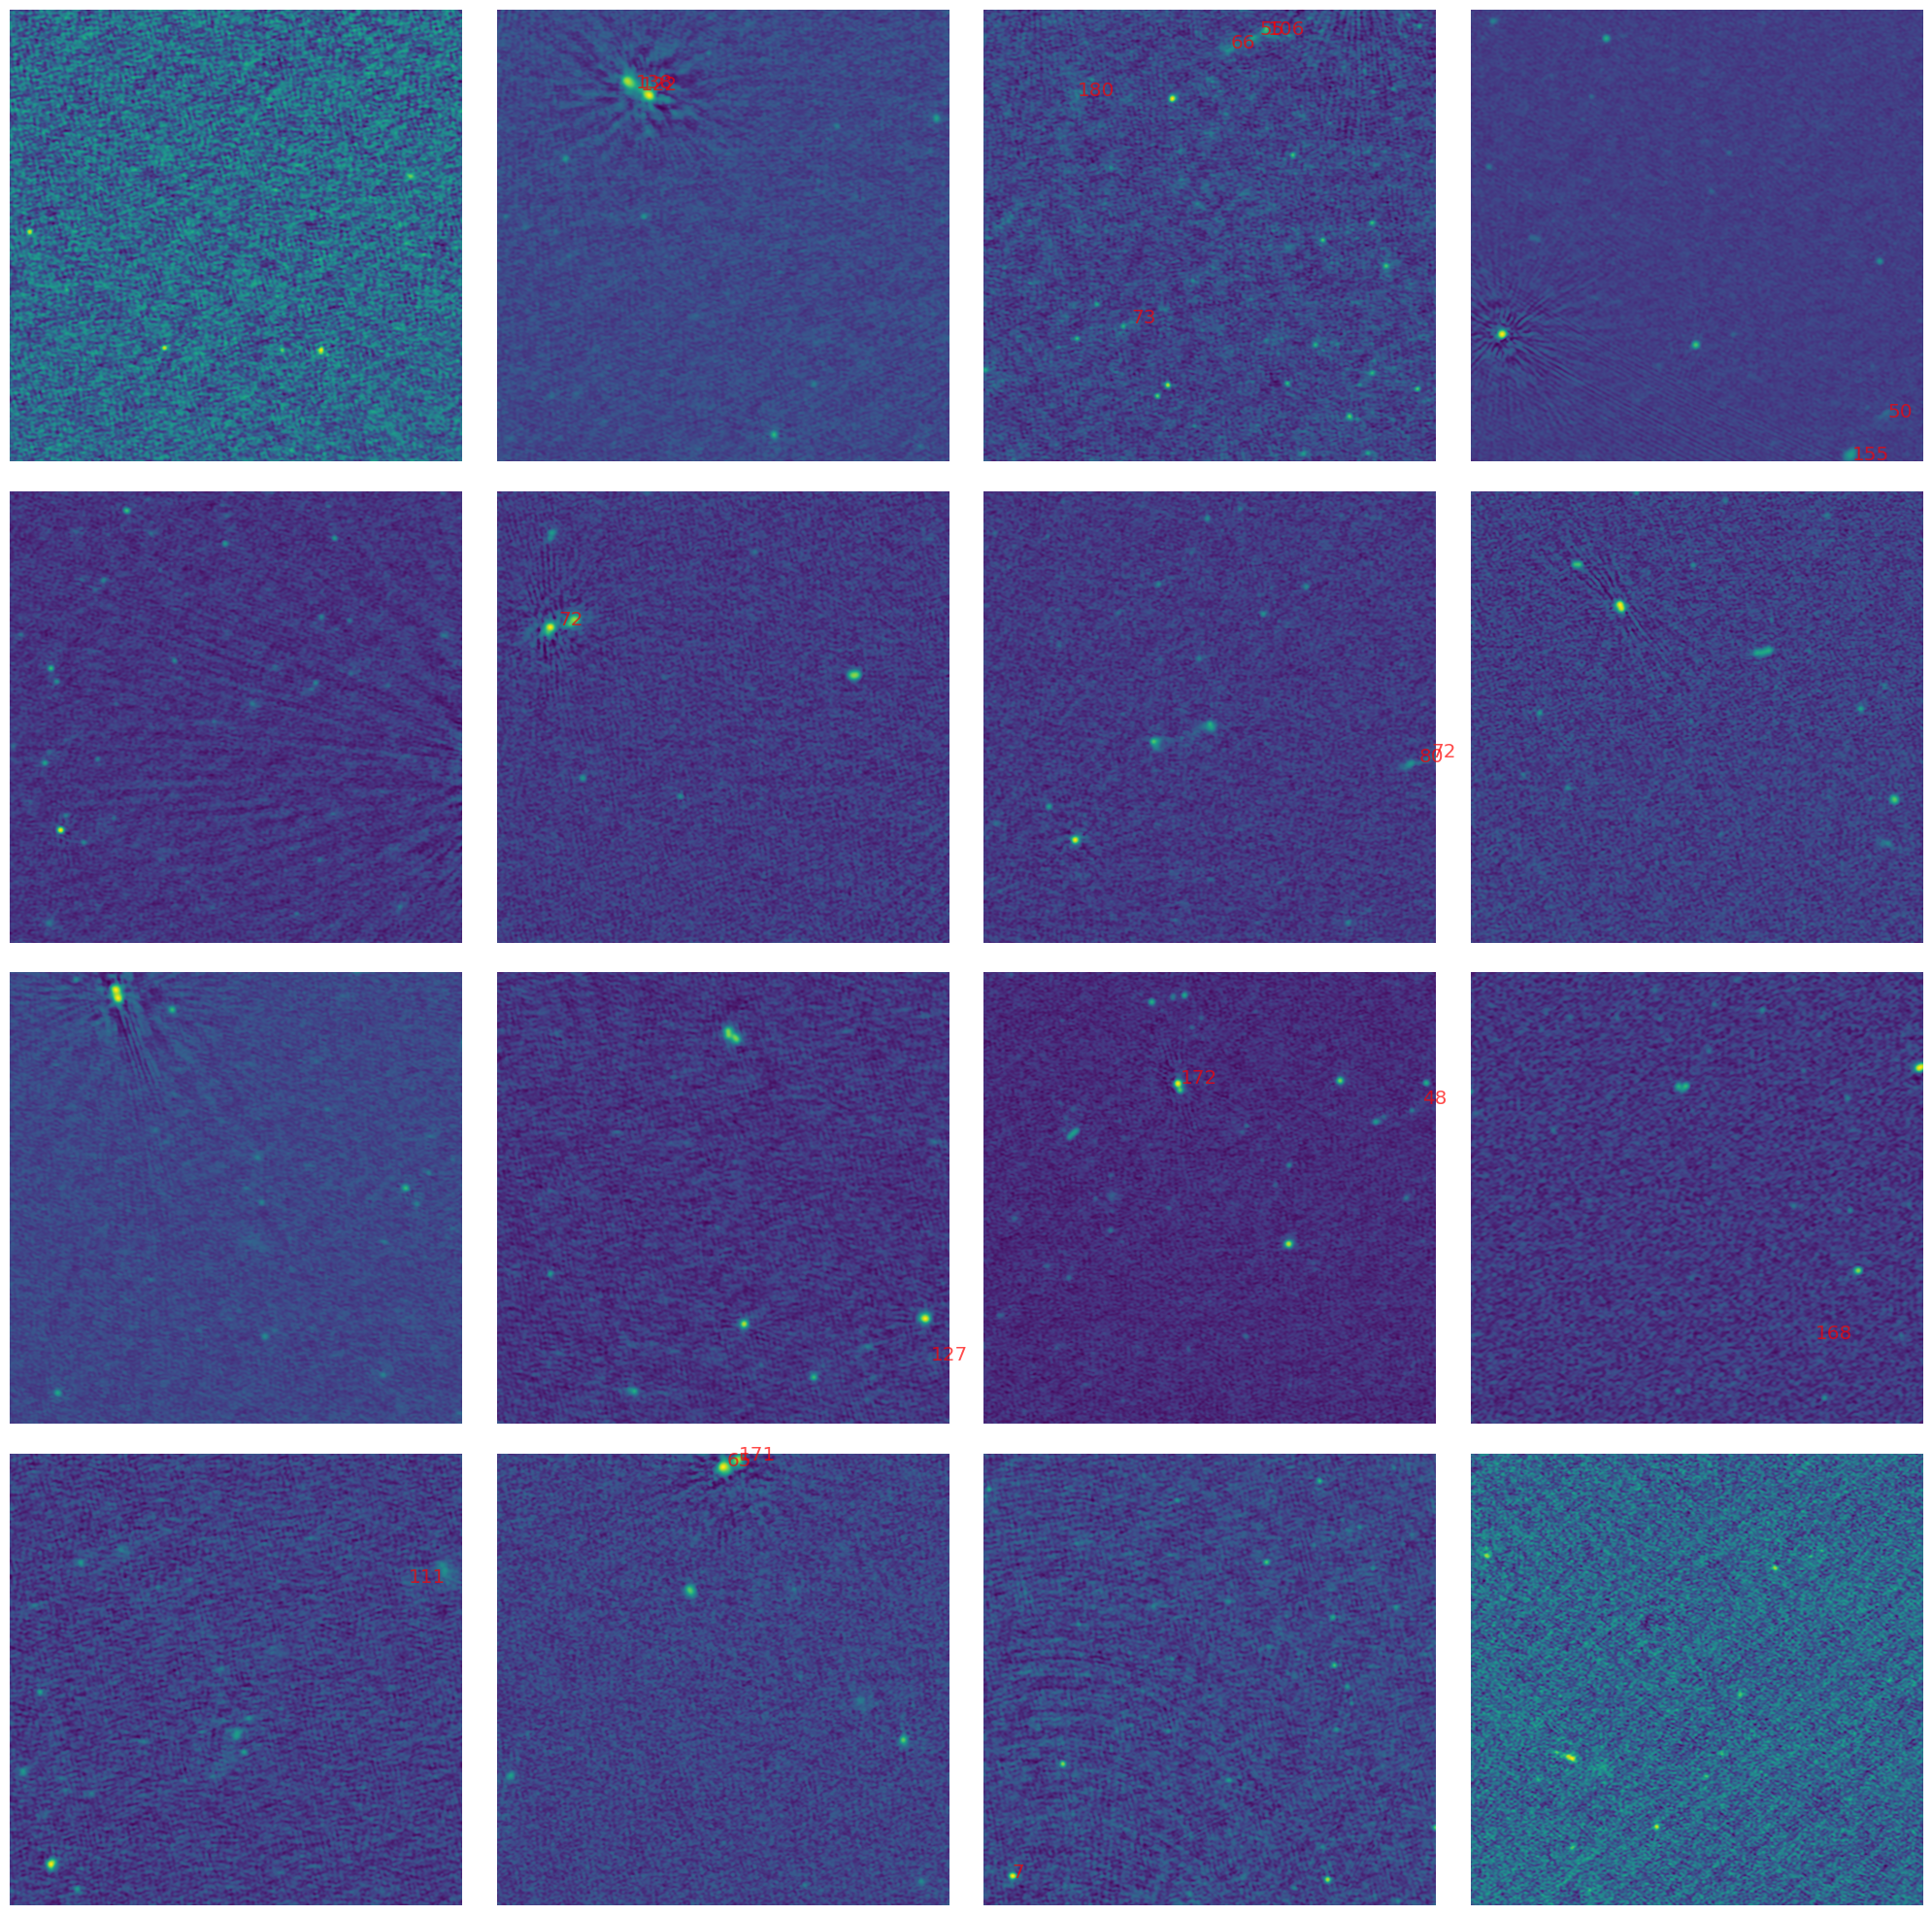

In [110]:
from plotting.images import plot_image_grid
from astropy.wcs import WCS
from data.obs.micromaps.utils import filter_catalog_by_wcs
import torch

fig, axs = plot_image_grid(maps)

for i, ax in enumerate(axs.flatten()):
    wcs = WCS(wcss[i])
    map_size = maps.shape[-1]
    wcs.pixel_shape = (map_size * 2, map_size * 2)
    pad = map_size // 2
    wcs = wcs[pad : -pad, pad : -pad]
    sub_cat = filter_catalog_by_wcs(dr3_cat, wcs)
    sub_cat = sub_cat[sub_cat.Maj > 30]
    px_coords = wcs.world_to_pixel_values(
        sub_cat["RA"].values,
        sub_cat["DEC"].values,
    )
    for i in range(len(px_coords[0])):
        ax.text(
            px_coords[0][i], 
            px_coords[1][i], 
            f"{sub_cat['PA'].values[i]:.0f}",
            color="red", 
            fontsize='x-large',
            alpha=0.7
        )


In [15]:
def make_random_pa(enc_ctxt):
    pos_flag = enc_ctxt[:, 0] > 0
    pa_vals = np.random.uniform(0, 180, size=pos_flag.sum())
    pas = np.zeros_like(pos_flag, dtype=float)
    pas[pos_flag] = pa_vals
    return pas

(array([64., 53., 43., 69., 45., 57., 41., 53., 57., 42.]),
 array([  0.60250069,  18.49855309,  36.39460549,  54.29065789,
         72.18671029,  90.08276269, 107.9788151 , 125.8748675 ,
        143.7709199 , 161.6669723 , 179.5630247 ]),
 <BarContainer object of 10 artists>)

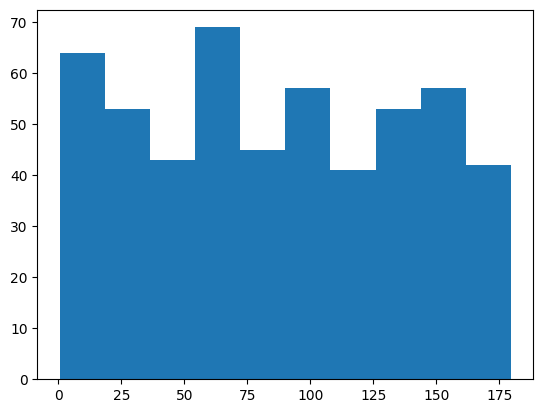

In [21]:
pa = make_random_pa(enc_ctxt)

plt.hist(pa[pa > 0].flatten())

(array([0.00302344, 0.00276712, 0.00272101, 0.00271256, 0.00269253,
        0.00270135, 0.00268824, 0.00270106, 0.00268306, 0.00268496,
        0.00267629, 0.00269355, 0.0026996 , 0.00266274, 0.00268933,
        0.00265473, 0.00268926, 0.00268896, 0.00268758, 0.00268875,
        0.00267301, 0.0026977 , 0.00270899, 0.00271912, 0.00273922,
        0.00273493, 0.00275153, 0.0028074 , 0.00279356, 0.00282918,
        0.00288271, 0.00287244, 0.00293465, 0.00296895, 0.00301885,
        0.00304696, 0.0031048 , 0.00311733, 0.00317603, 0.0032681 ,
        0.00331646, 0.00339506, 0.00342929, 0.00353054, 0.00363775,
        0.00372115, 0.00375444, 0.00384986, 0.00394571, 0.00405584,
        0.0041686 , 0.00425375, 0.00443045, 0.00455034, 0.00467788,
        0.00482094, 0.0050082 , 0.00510959, 0.00531602, 0.00546978,
        0.00570271, 0.00590936, 0.00614091, 0.00636474, 0.00660336,
        0.00683688, 0.00710893, 0.00743706, 0.00768449, 0.0080371 ,
        0.00835366, 0.00865324, 0.0090245 , 0.00

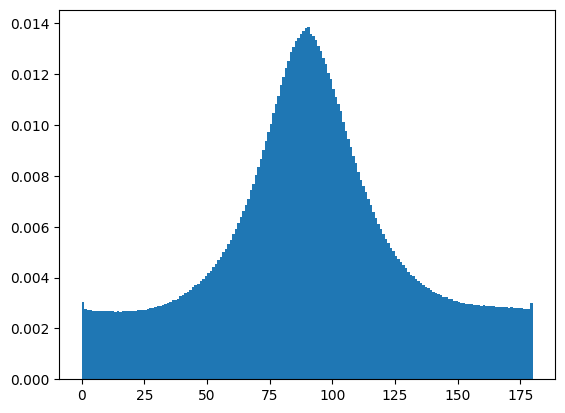

In [26]:
import matplotlib.pyplot as plt

plt.hist(dr3_cat["PA"], bins=180, density=True)

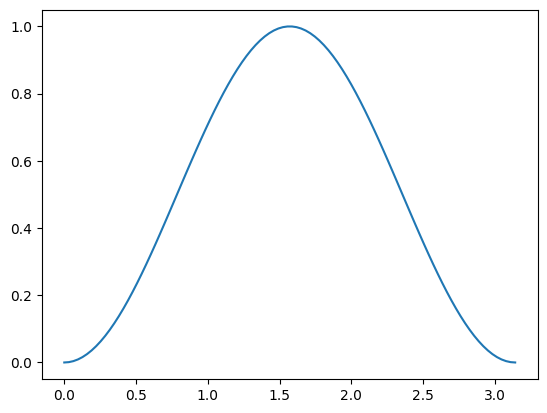

In [23]:
x = np.linspace(0, np.pi, 100)

plt.plot(x, np.sin(x)**2)

# Edge-Artifact Filtering

In [9]:
import data.sets.micromaps

reload(data.sets.micromaps)
from data.sets.micromaps import MicromapDatasetHF
import data.trf.post as post

dset = MicromapDatasetHF(
    "micromap-encodings-DR3-512",
    split="train",
    output_tuple=("__key__", "npy", "context_downscaled_d=2_f=2.npy"),
    post_transform=post.make_ctxt_to_topk(
        key="context_downscaled_d=2_f=2.npy", k=10, min_val=50
    ),
)

maps_dset = MicromapDatasetHF(
    "micromaps-DR3-512",
    split="train",
    output_tuple=("__key__", "npy"),
    mode="maps-scaled",
)

 14:34:45 (MMDsHF) - INFO : Loading arrow dataset from
	/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-512px-spacing=1/train.arrow


Loading dataset from disk:   0%|          | 0/256 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Extract topk vectors

In [ ]:
import copy

ctxt_dset = copy.deepcopy(dset.dataset).select_columns(
    ["context_downscaled_d=2_f=2.npy"]
)

In [ ]:
import copy
import torch
from tqdm import tqdm
from torch.utils.data import DataLoader

all_topk = torch.zeros((len(dset), 10, 3), dtype=torch.float32)
batch_size = 32
dl = DataLoader(
    ctxt_dset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=32,
    pin_memory=True,
    drop_last=False,
)

for i, batch in enumerate(tqdm(dl)):
    # print(type(batch), batch.keys())
    c = batch["context_downscaled_d=2_f=2.npy"]
    all_topk[i * batch_size : i * batch_size + c.shape[0]] = (
        post.ctxt_to_topk_functional(c, k=10, min_val=50)
    )

In [ ]:
torch.save(
    all_topk,
    paths.MICROMAP_SUBSETS_ARROW["micromap-encodings-DR3-512"]
    / "metadata/topk_k=10_min=50.pt",
)

### Filter dataset

In [ ]:
import torch

all_topk = torch.load(
    paths.MICROMAP_SUBSETS_ARROW["micromap-encodings-DR3-512"]
    / "metadata/topk_k=10_min=50.pt",
)

In [ ]:
from plotting.images import plot_image_grid


def plot_random_batch(maps_subset, n=36, i=None, **plot_kwargs):
    if i is None:
        i = np.random.choice(len(maps_subset) // n - 1)
    _, imgs = maps_subset.get_batch(
        i,
        n,
    )
    fig, axes = plot_image_grid(imgs, **plot_kwargs)
    return fig, axes, i

In [ ]:
len(dset), all_topk.shape

In [ ]:
fpeak.shape, dx.shape, dy.shape

In [ ]:
import copy

dx = all_topk[:, :, 0]
dy = all_topk[:, :, 1]
dx, dy, fpeak = all_topk.permute(2, 0, 1)

max_abs_pos = 0.6
min_fpeak = 200
getflag = lambda x: ((np.abs(x) < max_abs_pos) & (np.abs(x) > 0))
# The "Any is w.r.t. the topk-axis, i.e. any one good source in a cutout makes it valid"
flag = (getflag(dx) & getflag(dy) & (fpeak > min_fpeak)).any(axis=1)

maps_subset = copy.deepcopy(maps_dset).select(np.argwhere(flag)[0])

In [ ]:
n = 36

fig, axes, idx = plot_random_batch(
    maps_subset,
    n=36,
    # i=idx,
)
topk_sel = all_topk[flag][idx * n : (idx + 1) * n]

for i, ax in enumerate(axes.flatten()):
    dx, dy, fpeak = topk_sel[i].T.numpy()
    flg = (
        (np.abs(dx) < max_abs_pos)
        & (np.abs(dy) < max_abs_pos)
        & ((dx != 0) | (dy != 0))
        & (fpeak > min_fpeak)
    )
    if flg.sum() == 0:
        print(f"No valid positions for {i}")
    h = w = 512
    x = w // 2 + dx * w
    y = h // 2 + dy * h
    ax.scatter(y[flg], x[flg], marker="x", color="red")
    for j in range(len(x)):
        if flg[j]:
            ax.text(y[j], x[j], f"{fpeak[j]:.0}", color="red", fontsize=20, alpha=0.5)
    # pass
fig.show()

In [ ]:
# Save indices

sel_idxs = np.argwhere(flag)[0]

torch.save(
    sel_idxs,
    paths.MICROMAP_SUBSETS_ARROW["micromap-encodings-DR3-512"]
    / "metadata/selected_indices_pos<0.6_f>200.pt",
)

In [ ]:
dxsel, dysel = topk_sel[:, :, 0], topk_sel[:, :, 1]

getflagsel = lambda x: ((np.abs(x) < max_abs) & (np.abs(x) > 0))  # .any(axis=1)

getflagsel(dxsel) & getflagsel(dysel)

In [ ]:
print(
    topk_sel[2],
    "\n",
    (np.abs(topk_sel[2][:, 0]) < max_abs) & (np.abs(topk_sel[2][:, 1]) < max_abs),
)

In [ ]:
print(dxsel[2], dysel[2])

# Surrounding Sources Context

In [ ]:
import data.sets.micromaps
from deprecated.datasets import MicromapsDatasetLDM

reload(data.sets.micromaps)
import data.sets.datasets

reload(data.sets.datasets)
from data.sets.datasets import (
    MicromapsDatasetVAE,
    MicromapDatasetHF,
)

import data.trf.transforms as T

reload(T)

import data.trf.functional

reload(data.trf.functional)

from data.trf.scalers import ContextScaler
import data.trf.post as post

from torchvision.transforms.v2 import CenterCrop

reload(post)

# Load Context scalers
ctxt_scaler_keys = ["ctxt_scaler_ftot", "ctxt_scaler_fpeak", "ctxt_scaler_maj"]
ctxt_scalers = scaler_ftot, scaler_fpeak, scaler_maj = [
    ContextScaler.load(k) for k in ctxt_scaler_keys
]

# Define dataset arguments:
# Output tuple
out = (
    "npy",
    "context_downscaled.npy",
    "context_downscaled_d=2_f=2.npy",
    "__key__",
)
# Context transform
ctxt_scale_fn = data.trf.functional.make_catalog_context_value_scale(ctxt_scaler_keys)
ctxt_transform = {
    "context_downscaled.npy": T.CatalogContextTransform(scale_fn=ctxt_scale_fn),
    "context_downscaled_d=2_f=2.npy": T.CatalogContextTransform(scale_fn=ctxt_scale_fn),
}
# Post transforms
post_transforms = []
post_transforms.append(
    post.make_dependent_center_crop(
        crop_size=128,
        f=[1, 2],
        s=[1, 2],
        keys=("npy", "context_downscaled.npy", "context_downscaled_d=2_f=2.npy"),
    )
)
post_transforms.append(
    post.make_ctxt_to_topk(
        key="context_downscaled_d=2_f=2.npy",
        k=5,
        min_val=50,
    )
)

dset_name = "micromap-encodings-DR3-1024"
ldm_dset = MicromapDatasetHF(
    dset_name,
    output_tuple=out,
    split="train",
    ctxt_transform=ctxt_transform,
    post_transform=post.compose(*post_transforms),
    max_beam_arcsec=6.0,
)
maps_dset = MicromapDatasetHF(
    dset_name.replace("micromap-encodings", "micromaps"),
    split="train",
    output_tuple=(
        "__key__",
        "npy",
    ),
    mode="maps-scaled",
    post_transform=post.make_dependent_center_crop(crop_size=512, keys=("npy",)),
    max_beam_arcsec=6.0,
)
px_scaler = ldm_dset.scaler

In [ ]:
import torch

i_batch = 5
batch_size = 16
batch = ldm_dset.get_batch(i_batch, batch_size)
encodings, enc_ctxt, cat_ctxt, keys = batch
_, batch_maps = maps_dset.get_batch(i_batch, batch_size)
batch_maps = batch_maps.numpy()


import plotting.images

reload(plotting.images)
from plotting.images import plot_image_grid

fig, _ = plot_image_grid(batch_maps, n_cols=4)
fig.show()
# for i in range(enc_ctxt.shape[1]):
#     plot_image_grid(enc_ctxt[:, i], n_cols=4)

In [ ]:
from functools import reduce


def compose(*functions):
    return reduce(lambda f, g: lambda x: g(f(x)), functions, lambda x: x)

In [ ]:
x = cat_ctxt

# Mask out center crop
h, w = x.shape[-2:]
print(h, w)
x[:, :, h // 4 : -h // 4, w // 4 : -w // 4] *= 0

# Extract topk sources
sort_channel = 2
k = 10
# For every image in batch, get positions (x-y indices) of topk sources in sort_channel
# Vectorized: get top-k flattened indices per image for the chosen channel
batch_indices = torch.topk(x[:, sort_channel].flatten(start_dim=1), k=k, dim=1).indices
# print(batch_indices.shape, '\n', batch_indices)
values = torch.gather(
    x.flatten(start_dim=2)[:, 1:],
    2,
    batch_indices.unsqueeze(1).expand(-1, x.shape[1] - 1, -1),
)

# Turn flattened indices into x-y indices
dxy = batch_indices.unsqueeze(1).expand(-1, 2, -1).to(torch.float32)  # (B, 2, k)
h_norm = 2.0 / h  # Computed ONCE
w_norm = 2.0 / w  # Computed ONCE
dxy[:, 0] = (dxy[:, 0] // w) * h_norm - 1.0  # Uses pre-computed h_norm
dxy[:, 1] = (dxy[:, 1] % w) * w_norm - 1.0  # Uses pre-computed w_norm
values = torch.cat((dxy, values), dim=1)

In [ ]:
import matplotlib.pyplot as plt

# figure axis aspect 1:1 ratio
fig, ax = plt.subplots(
    1,
    1,
    figsize=(6, 6),
)
# kw = dict(histtype='step', log=True, bins=np.linspace(-1, 1, 21))
colors = plt.get_cmap("viridis")(np.linspace(0, 1, dxy.shape[0]))
for b, c in zip(dxy, colors):
    ax.scatter(*b.flatten(1).flip(0), color=c, label="dxy")
# ax.legend()
ax.grid(alpha=0.3)
ax.axis("equal")

plt.show()

Artifact context:

In [ ]:
import numpy as np
from scipy.signal import convolve2d, fftconvolve


def fft_convolve_batch(images, kernel):
    """Vectorized FFT convolution for batch of images with larger kernel"""
    s = kernel.shape  # Use kernel size for FFT
    kernel_fft = np.fft.fft2(kernel)
    images_fft = np.fft.fft2(images, s=s, axes=(1, 2))
    result = np.fft.ifft2(images_fft * kernel_fft[None, :, :], axes=(1, 2)).real

    # Crop to original image size
    h, w = images.shape[1:]
    return result[:, :h, :w]


def sparse_convolve_batch_vectorized(images, f):
    """
    Fully vectorized sparse convolution for batch of images.

    Args:
        images: 3D array (batch, height, width)
        f: function(r, phi) that defines the kernel

    Returns:
        3D array (batch, height, width)
    """
    batch_size, h, w = images.shape

    # Find non-zero pixels for all images
    batch_idx, y_coords, x_coords = np.where(images >= 1)
    values = images[batch_idx, y_coords, x_coords]

    # Create coordinate grids
    y_grid, x_grid = np.ogrid[:h, :w]

    # Calculate distances from each non-zero pixel (shape: n_pixels, h, w)
    dy = y_grid[None, :, :] - y_coords[:, None, None]
    dx = x_grid[None, :, :] - x_coords[:, None, None]

    r = np.sqrt(dx**2 + dy**2)
    phi = np.arctan2(dy, dx)

    # Evaluate kernel function
    kernels = f(r, phi) * values[:, None, None]  # (n_pixels, h, w)

    # Sum kernels for each image in batch using np.add.at
    result = np.zeros((batch_size, h, w))
    np.add.at(result, batch_idx, kernels)

    return result


def create_kernel_from_polar(shape, f, center=None):
    """
    Create a 2D kernel from a polar function f(r, phi).

    Args:
        shape: tuple (height, width) of the kernel
        f: function that takes (r, phi) and returns kernel values
        center: tuple (cy, cx) for kernel center, defaults to image center

    Returns:
        2D numpy array
    """
    h, w = shape

    # Default center to middle of image
    if center is None:
        center = (h // 2, w // 2)

    cy, cx = center

    # Create coordinate grids
    y, x = np.ogrid[:h, :w]

    # Calculate r and phi for each point
    dy = y - cy
    dx = x - cx
    r = np.sqrt(dx**2 + dy**2)
    phi = np.arctan2(dy, dx)

    # Apply the function
    kernel = f(r, phi)

    return kernel


# Example usage:
def my_filter(r, phi, omega=50):
    """Example: Gaussian with angular modulation"""
    return np.sin(omega * phi)


# Create kernel
image_shape = (2 * catalog_context_inp.shape[-1],) * 2
kernel = create_kernel_from_polar(image_shape, my_filter)

In [ ]:
plt.imshow(kernel)

In [ ]:
x = catalog_context_inp[:, 0:3:2].numpy().copy()

x[:, 1] = sparse_convolve_batch_vectorized(x[:, 1], my_filter)

In [ ]:
fig, axs = plot_image_grid(x.reshape(-1, *catalog_context_inp.shape[-2:]), n_cols=2)

for ax in axs.flatten():
    mask = catalog_context_inp[0, 0] == 0
    ax.contour(mask, colors="red", levels=[0.5], linewidths=0.5)

# Rarity Score

## Training data source stats

In [2]:
import data.utils

reload(data.utils)
from data.utils import parse_micromaps_path

import pandas as pd

dset = "micromap-encodings-DR3-512"
split = "test"

fpath = parse_micromaps_path(dset)


cat_file = fpath / f"catalogs/{split}.parquet"
cat = pd.read_parquet(cat_file)

In [ ]:
len(cat), len(cat.cutout_key.unique())

In [3]:
# Load dr3 catalog with matching columns
select_cols = cat.columns.tolist()
select_cols.remove("cutout_key")
dr3_cat = data.utils.load_lotss_catalog(select_cols=select_cols)

In [ ]:
# Define areas for normalization (in degsq)
mmap_size = int(dset.rsplit("-", 1)[-1])  # e.g., '1024'
area_mmaps = (mmap_size * 1.5 / 3600) ** 2 * len(cat.cutout_key.unique())  # in deg^2

area_dr3 = 19133.12

print(area_mmaps, area_dr3)

In [ ]:
import plotting.catalog

reload(plotting.catalog)
from plotting.catalog import holy_trinity_histograms

holy_trinity_histograms(
    [cat, dr3_cat],
    catalog_names=["Train Set", "LoTSS DR3"],
    show=True,
    areas_degsq=[area_mmaps, area_dr3],
)

## Write weights 

Load cutout-aware training set catalogs

In [4]:
from tqdm import tqdm
import pandas as pd

fpath = paths.MICROMAP_SUBSETS_ARROW["micromap-encodings-DR3-512"]

# splits = ["train", "val", "test"]
split = "test"

df = pd.read_parquet(fpath / f"catalogs/{split}.parquet")

keys = ["Total_flux", "Peak_flux", "Maj"]
ftot, fpeak, maj = data_arrays = np.stack([df[k].to_numpy() for k in keys])

### Source-Oriented Distributions

Define histogram bins with wide bins at the edges for outliers

In [ ]:
from plotting.utils import auto_log_bins

bin_dict = {}

for arr, key in zip(data_arrays, keys):
    # Auto logbins
    bins = auto_log_bins(arr, num=75)

    # Define bin range with minimum of 10 counts
    min_counts = 10
    counts, _ = np.histogram(arr, bins=bins)
    mask = counts >= min_counts
    mn, mx = min(bins[1:][mask]), max(bins[:-1][mask])

    # Make new bins and extend the outmost bins to include outliers
    bins = np.geomspace(mn, mx, 25)
    bins[0] = min(mn, arr.min() * 0.99)
    bins[-1] = max(mx, arr.max() * 1.01)
    bin_dict[key] = bins

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, arr, key in zip(axes, data_arrays, keys):
    bins = bin_dict[key]
    ax.hist(arr, bins=bins, histtype="step")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(key)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Counts")

fig.tight_layout()
fig.show()

Make 3D-Histogram with specified bins

In [ ]:
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

counts_3d, _ = np.histogramdd(
    (ftot, fpeak, maj),
    bins=list(bin_dict.values()),
)

# Make 3D plot with log counts
centers = lambda bins: 0.5 * (bins[1:] + bins[:-1])
coords = np.meshgrid(*[centers(bins) for bins in bin_dict.values()], indexing="ij")
coords = np.stack([c.ravel() for c in coords], axis=0)

fig, ax = plt.subplots(1, 1, figsize=(8, 8), subplot_kw={"projection": "3d"})
sc = ax.scatter(*np.log10(coords), c=np.log(counts_3d.flatten()), s=20, alpha=0.5)

# Provide the labels and right ticks
ax.set_xlabel("Total Flux")
ax.set_ylabel("Peak Flux")
ax.set_zlabel("Major Axis")
# ax.set_xticklabels(10**np.log(centers(bin_dict['Total_flux'])))
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_major_formatter(FuncFormatter(lambda x, pos: f"$10^{{{x:.0f}}}$"))

Assign sampling probs. based on counts

In [ ]:
iftot, ifpeak, imaj = [
    np.digitize(arr, bin_dict[key]) - 1 for arr, key in zip(data_arrays, keys)
]
count_score = counts_3d[iftot, ifpeak, imaj]

sampling_probs = 1 / count_score * 1 / (counts_3d > 0).sum()
print(sampling_probs.sum())
sampling_probs /= sampling_probs.sum()

In [ ]:
# Use this for peak flux only:
iftot, ifpeak, imaj = [
    np.digitize(arr, bin_dict[key]) - 1 for arr, key in zip(data_arrays, keys)
]
counts_1d = counts_3d.sum(axis=(0, 2))
count_score = counts_1d[ifpeak]

sampling_probs = 1 / count_score * 1 / (counts_1d > 0).sum()
print(sampling_probs.sum())
sampling_probs /= sampling_probs.sum()

Compare weighted and random sampling:

In [ ]:
n_samples = 10000

# Weighted
idx = np.random.choice(len(df), size=n_samples, replace=True, p=sampling_probs)
df_s = df.iloc[idx]
data_arrays_s = [df_s[k].to_numpy() for k in keys]

# Random
idx = np.random.choice(len(df), size=n_samples, replace=True)
df_r = df.iloc[idx]
data_arrays_r = [df_r[k].to_numpy() for k in keys]

# Plot histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, key in zip(axes, keys):
    bins = bin_dict[key]
    ax.hist(df_s[key], bins=bins, histtype="step", label="Weighted")
    ax.hist(df_r[key], bins=bins, histtype="step", label="Random")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(key)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Counts")

fig.tight_layout()
fig.show()

Implement rarity score for individual cutouts:

Define unique cutout keys

In [ ]:
cutout_keys_unique, i_cutout_keys, count = np.unique(
    df["cutout_key"], return_inverse=True, return_counts=True
)
plt.hist(count, bins=10, log=True)
plt.show()

Make dictionaries to assign probability scores and source values to every cutout:

In [ ]:
cutout_probs_dict = {i: [] for i in range(len(cutout_keys_unique))}
cutout_data_array_dict = {i: [] for i in range(len(cutout_keys_unique))}

for i in tqdm(range(len(df))):
    cutout_probs_dict[i_cutout_keys[i]].append(sampling_probs[i])
    cutout_data_array_dict[i_cutout_keys[i]].append(data_arrays.T[i])

cutout_probs_dict = {i: np.array(v) for i, v in tqdm(cutout_probs_dict.items())}
cutout_data_array_dict = {
    i: np.stack(v).T for i, v in tqdm(cutout_data_array_dict.items())
}

### Cutout-Oriented Distributions

Gather data array (ftot, fpeak, maj) per cutout

In [5]:
cutout_keys_unique, i_cutout_keys, count = np.unique(
    df["cutout_key"], return_inverse=True, return_counts=True
)
cutout_data_array_dict = {i: [] for i in range(len(cutout_keys_unique))}

for i in tqdm(range(len(df))):
    d = data_arrays.T[i]
    cutout_data_array_dict[i_cutout_keys[i]].append(data_arrays.T[i])

cutout_data_array_dict = {
    i: np.stack(v).T for i, v in tqdm(cutout_data_array_dict.items())
}

100%|██████████| 59955/59955 [00:01<00:00, 47143.74it/s]


Define per-cutout p-scores

In [6]:
# Here: Use maximum fpeak
arr = cutout_fpeak_max = np.array(
    [v[1].max() for i, v in tqdm(cutout_data_array_dict.items())]
)

100%|██████████| 59955/59955 [00:00<00:00, 450285.33it/s]


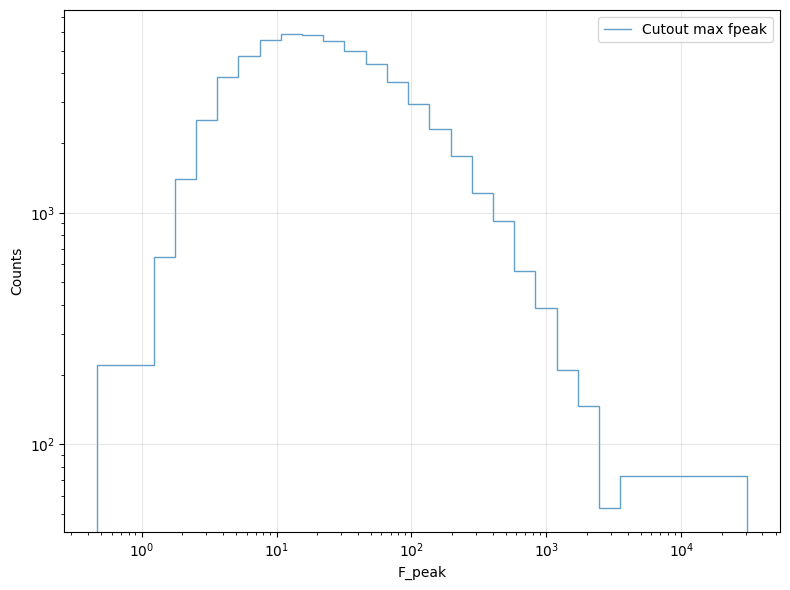

In [8]:
from plotting.utils import auto_log_bins

# Plot distribution
bins = auto_log_bins(cutout_fpeak_max, num=75)

# Define bin range with minimum of 10 counts
min_counts = 10
counts, _ = np.histogram(arr, bins=bins)
mask = counts >= min_counts
mn, mx = min(bins[1:][mask]), max(bins[:-1][mask])

# Make new bins and extend the outmost bins to include outliers
bins = np.geomspace(mn, mx, 25)
bins[0] = min(mn, arr.min() * 0.99)
bins[-1] = max(mx, arr.max() * 1.01)

# Re-do the histogram with new bins
counts, _ = np.histogram(arr, bins=bins)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# ax.hist(arr, bins=bins, histtype="step", alpha=0.7)
ax.stairs(counts, bins, label="Cutout max fpeak", alpha=0.7)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("F_peak")
ax.grid(alpha=0.3)
ax.set_ylabel("Counts")
ax.legend()

fig.tight_layout()
fig.show()

In [9]:
# Give every cutout its respective bin index
i_cut = np.digitize(arr, bins) - 1
# Define score
count_score = counts[i_cut]

sampling_probs = 1 / count_score * 1 / (counts > 0).sum()
print(sampling_probs.sum())
sampling_probs /= sampling_probs.sum()

# Define probs dict for compatibility with source-oriented method
# (So we can use the same cells for sampling, plotting and saving below)
cutout_probs_dict = {i: np.array([p]) for i, p in enumerate(sampling_probs)}

1.0


### Test Sampling & Save

#### Test & Plot

Define rarity score for each cutout, sample, and gather source data from sampled cutouts

In [10]:
def topk(arr, k=3):
    if len(arr) < k:
        return arr
    else:
        return np.partition(arr, -k)[-k:]


# Define rarity scores as sampling probs:
# What happens to v in this loop is how probability scores are assembled from
# all sources in one cutout.
weights_fn = lambda p: p.max()  # p.sum()**4 + p.prod()
scores = np.array([weights_fn(probs) for probs in tqdm(cutout_probs_dict.values())])
print(scores.sum())
scores /= scores.sum()

# Sample cutouts:
# Weighted sampling
n_cutouts = 100000
idx = np.random.choice(len(cutout_keys_unique), size=n_cutouts, replace=True, p=scores)
data_arrays_cs = np.concatenate([cutout_data_array_dict[i] for i in tqdm(idx)], axis=1)
fmax_cs = np.array([cutout_data_array_dict[i][1].max() for i in tqdm(idx)])
fmean_cs = np.array([cutout_data_array_dict[i][1].mean() for i in tqdm(idx)])
print(data_arrays_cs.shape)

# Random sampling
idx = np.random.choice(len(cutout_keys_unique), size=n_cutouts, replace=True)
data_arrays_cr = np.concatenate([cutout_data_array_dict[i] for i in tqdm(idx)], axis=1)
fmax_cr = np.array([cutout_data_array_dict[i][1].max() for i in tqdm(idx)])
fmean_cr = np.array([cutout_data_array_dict[i][1].mean() for i in tqdm(idx)])
print(data_arrays_cr.shape)

100%|██████████| 59955/59955 [00:00<00:00, 392004.17it/s]


1.0


100%|██████████| 100000/100000 [00:00<00:00, 224125.46it/s]


(3, 3027698)


100%|██████████| 100000/100000 [00:00<00:00, 220740.41it/s]

(3, 3328926)


NameError: name 'bin_dict' is not defined

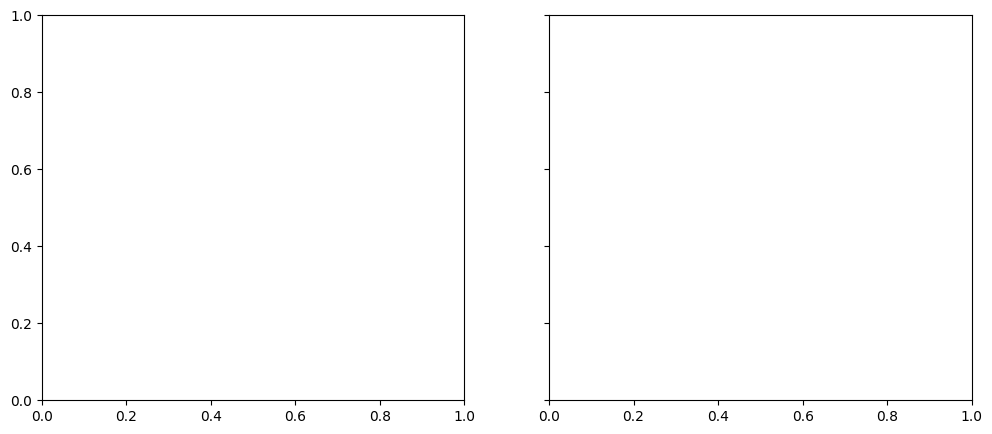

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

bins = bin_dict["Peak_flux"]
# ax.hist(df_s[key], bins=bins, histtype="step", label="Weighted")
# ax.hist(df_r[key], bins=bins, histtype="step", label="Random")
axs[0].hist(fmax_cs, bins=bins, histtype="step", label="Weighted cutout sampling")
axs[0].hist(fmax_cr, bins=bins, histtype="step", label="Random cutout sampling")
axs[0].set_xlabel("Max. Peak_flux")

axs[1].hist(fmean_cs, bins=bins, histtype="step", label="Weighted cutout sampling")
axs[1].hist(fmean_cr, bins=bins, histtype="step", label="Random cutout sampling")
axs[1].set_xlabel("Mean Peak_flux")

for ax in axs.flatten():
    ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.grid(alpha=0.3)
    ax.legend()
    ax.set_ylabel("Counts")
    ax.legend()

fig.tight_layout()
fig.show()

NameError: name 'bin_dict' is not defined

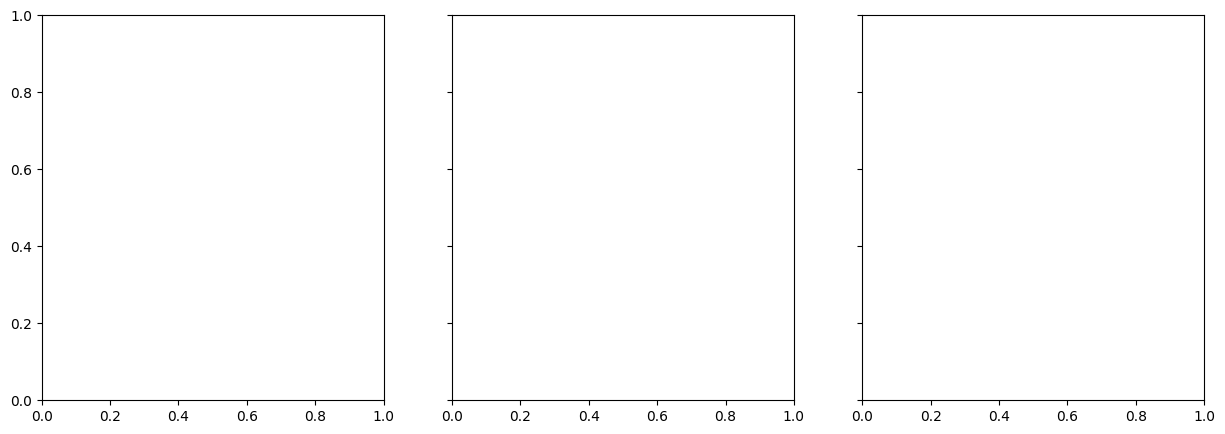

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, (ax, key) in enumerate(zip(axes, keys)):
    bins = bin_dict[key]
    # ax.hist(df_s[key], bins=bins, histtype="step", label="Weighted")
    # ax.hist(df_r[key], bins=bins, histtype="step", label="Random")
    ax.hist(
        data_arrays_cs[i], bins=bins, histtype="step", label="Weighted cutout sampling"
    )
    ax.hist(
        data_arrays_cr[i], bins=bins, histtype="step", label="Random cutout sampling"
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(key)
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Counts")

fig.tight_layout()
fig.show()

Experiment: Look at different distributions in max(f_peak) for different weight functions:

In [13]:
def topk(arr, k=3):
    if len(arr) < k:
        return arr
    else:
        return np.partition(arr, -k)[-k:]


# Define rarity scores as sampling probs:
# What happens to v in this loop is how probability scores are assembled from
# all sources in one cutout.
gammas = np.linspace(0.5, 1.0, 6)

fmax_cs_list = []
for gamma in tqdm(gammas):
    weights_fn = lambda p: p.max() ** gamma  # + p.prod()
    scores = np.array([weights_fn(probs) for probs in cutout_probs_dict.values()])
    # print(scores.sum())
    scores /= scores.sum()

    # Sample cutouts:
    # Weighted sampling
    n_cutouts = 100000
    idx = np.random.choice(
        len(cutout_keys_unique), size=n_cutouts, replace=True, p=scores
    )
    data_arrays_cs = np.concatenate([cutout_data_array_dict[i] for i in idx], axis=1)
    fmax_cs = np.array([cutout_data_array_dict[i][1].max() for i in idx])
    # print(data_arrays_cs.shape)
    fmax_cs_list.append(fmax_cs)

# Random sampling
idx = np.random.choice(len(cutout_keys_unique), size=n_cutouts, replace=True)
data_arrays_cr = np.concatenate([cutout_data_array_dict[i] for i in tqdm(idx)], axis=1)
fmax_cr = np.array([cutout_data_array_dict[i][1].max() for i in tqdm(idx)])
print(data_arrays_cr.shape)

100%|██████████| 100000/100000 [00:00<00:00, 363179.68it/s]

(3, 3309993)


NameError: name 'bin_dict' is not defined

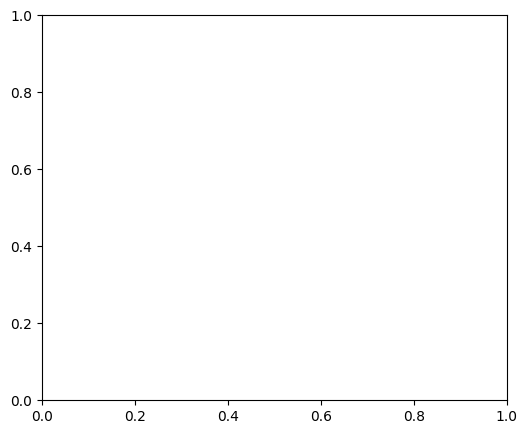

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharey=True)

bins = bin_dict["Peak_flux"]
# ax.hist(df_s[key], bins=bins, histtype="step", label="Weighted")
# ax.hist(df_r[key], bins=bins, histtype="step", label="Random")
cmap = plt.get_cmap("tab10")
for i in range(len(fmax_cs_list)):
    ax.hist(
        fmax_cs_list[i],
        bins=bins,
        histtype="step",
        label=rf"$\gamma$={gammas[i]:.3f}",
        color=cmap(i / len(fmax_cs_list)),
    )

ax.hist(fmax_cr, bins=bins, histtype="step", label="Random cutout sampling")
ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlabel("Max. Peak_flux")
ax.grid(alpha=0.3)
ax.legend()

ax.set_ylabel("Counts")

fig.tight_layout()
fig.show()

In [ ]:
unique_sampled_cutouts, counts = np.unique(idx, return_counts=True)
plt.hist(counts, bins=np.arange(1, counts.max() + 1) - 0.5, log=True)

#### Save

Save dictionary with sampling probs:

In [15]:
probs_with_cutout_key = {
    cutout_keys_unique[i]: cutout_probs_dict[i]
    for i in tqdm(range(len(cutout_keys_unique)))
}

np.save(
    fpath / f"metadata/cutout_sampling_probs_fmax_{split}.npy",
    probs_with_cutout_key,
    allow_pickle=True,
)

100%|██████████| 59955/59955 [00:00<00:00, 2071480.91it/s]


In [ ]:
loaded = np.load(
    fpath / f"metadata/cutout_sampling_probs_fmax_{split}.npy", allow_pickle=True
)

In [ ]:
type(loaded.item())

In [ ]:
import torch

ckpt = torch.load(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/model_results/LDM-Denoiser-EmbCC-128-debug/lightning/ckpt_nan_debug_00000000.pt",
    map_location="cpu",
)

In [ ]:
ckpt.keys()

## Look at examples

In [ ]:
import data.sets.micromaps

reload(data.sets.micromaps)

from data.sets.micromaps import MicromapDatasetHF

maps_dset = MicromapDatasetHF(
    dset="micromaps-DR3-512",
    split=split,
    mode="maps-scaled",
    output_tuple=("npy", "__key__"),
    weights_file=fpath / f"metadata/cutout_sampling_probs_{split}.npy",
)

In [ ]:
len(maps_dset), len(cutout_keys_unique)

In [ ]:
fmax = np.array([x[1].max() for x in tqdm(cutout_data_array_dict.values())])

In [ ]:
from plotting.images import plot_image_grid

condition = np.logical_and(1e1 <= fmax, fmax <= 5e1)
condition_ii = np.argwhere(condition).flatten()
print(condition.sum())

valid_keys = np.array(cutout_keys_unique)[condition]
n_images = 32
ii = np.random.randint(0, len(valid_keys), size=n_images)
mmaps, keys = maps_dset[condition_ii[ii]]

assert all(keys == valid_keys[ii])

fig, _ = plot_image_grid(mmaps, n_cols=4)

## Test weighted random dataset

In [ ]:
import utils.my_logging

reload(utils.my_logging)

import data.sets.micromaps

reload(data.sets.micromaps)
from data.sets.micromaps import MicromapDatasetHF

import data.trf.post as post

reload(post)

import data.trf.transforms as T

reload(T)

split = "train"

dset = MicromapDatasetHF(
    "micromap-encodings-DR3-512",
    # weights_file=f"cutout_sampling_probs_{split}.npy",
    weights_fn=lambda x: x.sum() ** 2 + x.prod(),
    split=split,
    output_tuple=(
        "npy",
        # "context_downscaled.npy",
        "context_downscaled_d=2_f=2.npy",
        "__key__",
    ),
    ctxt_transform={"context_downscaled_d=2_f=2.npy": T.CatalogContextTransform()},
    # max_beam_arcsec=6,
    post_transform=post.make_ctxt_to_topk(
        key="context_downscaled_d=2_f=2.npy", k=5, min_val=10
    ),
)

In [ ]:
dset[0]

In [ ]:
dl = dset.get_dataloader(batch_size=16, num_workers=8, shuffle=True)

In [ ]:
it = iter(dl)

In [ ]:
next(it)

In [ ]:
import pandas as pd

pointing_info_df = pd.read_csv(
    paths.LOFAR_DATA_PARENT / "DR3_pointing_lookup.csv", index_col="mosaic"
)

In [ ]:
from tqdm import tqdm

max_beam_arcsec = 6

good_pointings = np.array(
    pointing_info_df.index[
        pointing_info_df["Beam"] <= np.round(max_beam_arcsec / 3600, 5)
    ]
)
good_pointings

In [ ]:
keys = np.array(dset.dataset["__key__"], dtype=np.str_)

In [ ]:
np.isin(
    np.char.partition(keys, "-")[:, 0], np.array(list(good_pointings), dtype=np.str_)
).sum()

In [ ]:
np.char.partition(keys, "-")[:, 0].shape, np.array(good_pointings).shape

In [ ]:
np.array(list(good_pointings))

Combine to single dataset:

In [ ]:
from datasets import load_from_disk, load_dataset, concatenate_datasets
from pathlib import Path
from tqdm import tqdm

arrow_path = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-512px-spacing=1"
)
splits = ["train", "val", "test"]

for split in splits:
    parent = arrow_path / split
    files = sorted(list(parent.glob("*.arrow")))
    ds_list = []
    for f in tqdm(files, desc=f"Loading {split}"):
        ds = load_from_disk(str(f))
        ds_list.append(ds)
    ds = concatenate_datasets(ds_list)
    print(f"{split}: {len(ds)} samples")
    ds.save_to_disk(str(arrow_path / split / f"combined"), num_shards=16, num_proc=8)

In [ ]:
import pandas as pd
import pyarrow as pa

ds = load_from_disk(
    "/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps-arrow/micromap_encodings-DR3-512px-spacing=1/train/combined"
)

In [ ]:
len(ds)

In [ ]:
import webdataset as wds

shard_path = arrow_path.replace(".arrow", ".tar").replace(
    "micromaps-arrow", "micromaps"
)

ds = wds.WebDataset(
    str(shard_path), handler=lambda e: None, shardshuffle=False
)  # ignore errors

In [ ]:
from tqdm import tqdm

for sample in tqdm(ds):
    pass

In [ ]:
loader = dset.get_dataloader(
    batch_size=16,
    shuffle=True,
    persistent_workers=False,
    num_workers=16,
    # timeout=60,
)
it = iter(loader)

In [ ]:
from datetime import datetime, timedelta

tt = []
t0 = datetime.now()
for batch in tqdm(loader):
    tt.append(timedelta(seconds=(datetime.now() - t0).total_seconds()))

In [ ]:
dset[0]

# HF Dataset Implementations

In [ ]:
out_parent = paths.MICROMAP_SUBSETS_ARROW["micromaps-DR3-1024"]

import data.obs.micromaps.arrow_utils as au
import pyarrow as pa
import pyarrow.dataset as ds
from datasets import load_from_disk
from tqdm import tqdm

splits = ["train", "val", "test"]
for split in tqdm(splits):
    au.create_dataset_info(
        out_parent / f"{split}.arrow",
        out_parent.name,
        split=split,
        write=True,
    )
    au.create_state_json(out_parent / f"{split}.arrow")

## Load Datasets & Check

In [ ]:
import data.sets.micromaps

reload(data.sets.micromaps)
from data.sets.micromaps import MicromapDatasetHF

dset = MicromapDatasetHF(
    "micromaps-DR3-1024",
    split="val",
    mode="raw",
)

In [ ]:
dset.split

In [ ]:
dset.dataset.cleanup_cache_files()

In [ ]:
from plotting.images import plot_image_grid

dset.set_transforms("maps-scaled")
(batch,) = next(iter(dset.get_dataloader(batch_size=16, num_workers=16)))

fig, _ = plot_image_grid(batch, n_cols=4)

In [ ]:
import data.sets.micromaps

reload(data.sets.micromaps)
from data.sets.micromaps import MicromapDatasetHF
import data.trf.post as post

reload(post)
import data.trf.transforms as T

reload(T)

output_tuple = (
    "__key__",
    "npy",
    "context_downscaled.npy",
    "context_downscaled_d=2_f=2.npy",
)

ctxt_transform = (
    {
        "context_downscaled.npy": T.CatalogContextTransform(),
        "context_downscaled_d=2_f=2.npy": T.CatalogContextTransform(),
    },
)

dset = MicromapDatasetHF(
    "micromap-encodings-DR3-512",
    split="train",
    # post_transform=post.make_ctxt_to_topk(key="context_downscaled_d=2_f=2.npy", k=5),
    output_tuple=output_tuple,
    # ctxt_transform=ctxt_transform,
    mode="raw",
)

loader = dset.get_dataloader(batch_size=16, num_workers=32)

In [ ]:
dset.dataset.cleanup_cache_files()

In [ ]:
for i, x in tqdm(
    enumerate(dset.dataset["context_downscaled_d=2_f=2.npy"]), total=len(dset)
):
    if np.isnan(x).any():
        print(f"Found NaN in sample {i}: {dset.dataset['__key__'][i]}")

In [ ]:
from tqdm import tqdm
import torch

# Loop one epoch and check for NaN values

## Make Dataset

In [ ]:
import data.obs.micromaps.arrow_utils as au

reload(au)
from data.utils import parse_dset_path

col = au.extract_column("micromap-encodings-DR3-512", "train", "__key__")

In [ ]:
from tqdm import tqdm, trange

keys, _, centers = np.char.partition(col, sep="-").T
unique_keys, u_idx = np.unique(keys, return_inverse=True)


centers = {
    unique_keys[i]: np.stack(np.char.split(centers[u_idx == i], "-", 2)).astype(int)
    for i in trange(len(unique_keys))
}

In [ ]:
centers[unique_keys[0]]

In [ ]:
def diagnose_arrow_file(filepath):
    """Diagnose what format an .arrow file actually is."""
    import pyarrow as pa
    import pyarrow.ipc as ipc
    import pyarrow.parquet as pq

    filepath = Path(filepath)

    print(f"\n=== Diagnosing {filepath.name} ===")
    print(f"Size: {filepath.stat().st_size / 1024 / 1024:.2f} MB")

    # Read first 100 bytes to check magic bytes
    with open(filepath, "rb") as f:
        header = f.read(100)
        print(f"First 20 bytes (hex): {header[:20].hex()}")
        print(f"First 20 bytes (str): {header[:20]}")

    # Try different formats
    formats_tried = []

    # 1. Try Arrow IPC (stream format)
    try:
        with pa.memory_map(str(filepath), "r") as source:
            reader = ipc.open_stream(source)
            schema = reader.schema
            print(f"✅ Arrow IPC Stream format detected")
            print(f"   Schema: {schema}")
            formats_tried.append(("Arrow IPC Stream", True, schema))
            return "ipc_stream", schema
    except Exception as e:
        formats_tried.append(("Arrow IPC Stream", False, str(e)[:100]))

    # 2. Try Arrow IPC (file format)
    try:
        with pa.memory_map(str(filepath), "r") as source:
            reader = ipc.open_file(source)
            schema = reader.schema
            print(f"✅ Arrow IPC File format detected")
            print(f"   Schema: {schema}")
            formats_tried.append(("Arrow IPC File", True, schema))
            return "ipc_file", schema
    except Exception as e:
        formats_tried.append(("Arrow IPC File", False, str(e)[:100]))

    # 3. Try Parquet
    try:
        table = pq.read_table(str(filepath))
        schema = table.schema
        print(f"✅ Parquet format detected")
        print(f"   Schema: {schema}")
        formats_tried.append(("Parquet", True, schema))
        return "parquet", schema
    except Exception as e:
        formats_tried.append(("Parquet", False, str(e)[:100]))

    # 4. Try Feather (Arrow IPC in disguise)
    try:
        import pyarrow.feather as feather

        table = feather.read_table(str(filepath))
        schema = table.schema
        print(f"✅ Feather format detected")
        print(f"   Schema: {schema}")
        formats_tried.append(("Feather", True, schema))
        return "feather", schema
    except Exception as e:
        formats_tried.append(("Feather", False, str(e)[:100]))

    # Nothing worked
    print("\n❌ Could not detect format. Tried:")
    for fmt, success, result in formats_tried:
        status = "✅" if success else "❌"
        print(f"  {status} {fmt}: {result if not success else 'Success'}")

    return None, None

In [ ]:
f = sorted(list(path.iterdir()))[0]
print(f)

diagnose_arrow_file(str(sorted(list(path.iterdir()))[0]))

## Add contexts

In [ ]:
import data.obs.micromaps.utils

reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import maps_to_encoding_path

from data.utils import parse_dset_path

maps_dset_path = parse_dset_path(
    "micromaps-DR3-512", lookup=paths.MICROMAP_SUBSETS_ARROW
)
encs_dset_path = maps_to_encoding_path(maps_dset)

In [ ]:
import datasets

split = "train"
maps_dset = datasets.load_from_disk(str(maps_dset_path / f"{split}.arrow")).sort(
    "__key__"
)

In [ ]:
encs_dset = datasets.load_from_disk(str(encs_dset_path / f"{split}.arrow")).sort(
    "__key__"
)

In [ ]:
(
    encs_dset.with_format("pandas")["__key__"]
    == maps_dset.with_format("pandas")["__key__"]
).all()

In [ ]:
len(encs_dset.cache_files)

In [ ]:
2 ** int(np.log2(257))

In [ ]:
ids = encs_dset.with_format("pandas")["__key__"].str.split("-", n=1).str.get(0)
unique_ids = ids.unique()

In [ ]:
idxs = np.argwhere(ids == unique_ids[0])

In [ ]:
len(idxs)

In [ ]:
encs_dset.select(idxs.flatten())

In [ ]:
import pandas as pd
import pyarrow.dataset as ds

table = (
    ds.dataset(str(encs_dset_path / f"{split}.arrow"), format="arrow")
    .to_table(columns=["__key__"])
    .to_pandas()
)

# Check context and file contents

In [ ]:
import tarfile
from pathlib import Path

# Get the dataset path and first few URLs
base_path = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-DR3-512px-spacing=1/train"
)
urls = sorted(list(base_path.glob("*.tar")))[:5]  # First 5 URLs

print("Manual inspection of URLs:")
total_samples_manual = 0
for i, url in enumerate(urls):
    with tarfile.open(url, "r") as tar:
        # Count .npy files (excluding context files)
        sample_files = [
            name.split(".")[0]
            for name in tar.getnames()
            if name.endswith(".npy") and "context" not in name
        ]
        print(
            f"URL {i+1}: {url.name} -> {len(sample_files)} samples, {len(set(sample_files))} unique keys"
        )
        total_samples_manual += len(sample_files)
        if i == 0:  # Show samples from first URL
            print(f"  All entries: {tar.getnames()}")
            print(
                f"  Unique extensions: {set([name.split('.', 1)[1] for name in tar.getnames()])}"
            )
        for member in tar.getmembers():
            if member.isfile():
                # The key is the base name without extension, e.g. "pointing-x-y"
                key = member.name.split(".")[0]
                ext = ".".join(member.name.split(".")[1:])
                if ext == (f"context_f={2}.npy"):
                    print(f"{key}.{ext}")

print(f"\nTotal samples in first 5 URLs: {total_samples_manual}")

In [ ]:
# Now test webdataset behavior
print(f"\nTesting current webdataset configuration...")
loader_test = WebLoader(ldm_dset, batch_size=1, num_workers=0)
url_counts = {}
sample_count = 0

for i, batch in enumerate(loader_test):
    enc, ctxt, urls, keys = batch
    url = urls[0]
    if url not in url_counts:
        url_counts[url] = 0
    url_counts[url] += 1
    sample_count += 1

    # Stop after processing a reasonable number
    if sample_count >= 20:
        break

print(f"Webdataset processed {sample_count} samples from {len(url_counts)} URLs:")
for url, count in url_counts.items():
    print(f"  {Path(url).name}: {count} samples")

if len(url_counts) < 5 and max(url_counts.values()) == 1:
    print("❌ CONFIRMED: Only getting 1 sample per URL!")
    print("The issue is in the webdataset configuration.")
else:
    print("✅ Webdataset seems to be working correctly.")

Calculate sampling weights based on bin counts:

In [ ]:
import torch

# loader_it = iter(loader)
# i = 5
# for _ in range(i):
# batch = next(loader_it)
batch = next(loader_it)
encodings, ctxt, urls, keys = batch
batch_maps = get_micromap(urls, keys)

do_crop = False

print(encodings.shape, ctxt.shape, batch_maps.shape)

from torchvision.transforms.v2.functional import crop

# Crop encodings
if do_crop:
    h = 32
    crop_args = lambda h: [h // 2, h // 2, h, h]
    cr = crop(torch.cat([encodings, ctxt], dim=1), *crop_args(h))
    encodings, ctxt = cr[:, : encodings.shape[1]], cr[:, encodings.shape[1] :]

    # Crop maps
    h *= 4
    batch_maps = crop(torch.from_numpy(batch_maps), *crop_args(h))

import plotting.images

reload(plotting.images)
from plotting.images import plot_image_grid

n_plot = 16
fig, _ = plot_image_grid(batch_maps[:n_plot], n_cols=4)
fig.show()
for i in range(ctxt.shape[1]):
    plot_image_grid(ctxt[:n_plot, i], n_cols=4)

In [ ]:
for i in range(4):
    print((ctxt[:, i] != 0).sum())

In [ ]:
ctxt_flat = ctxt.numpy().ravel()
(ctxt_flat != 0).sum() / len(ctxt_flat),

Plot histograms from weighted sampling:

In [ ]:
<button type="button" id="action" class="btn btn-xs btn-default download-item" data-url="https://repository.surfsara.nl/datasets/lotss-dr2/P000-23/files/mosaic.pybdsmmask.fits"><span class="glyphicon glyphicon-download-alt" aria-hidden="true"></span> Download</button>

In [ ]:
from data.utils import load_fits_image

img, wcs = load_fits_image(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/bdsf_products/P000-23/mosaic.pybdsmmask.fits"
)

In [ ]:
nonzero_flag.sum(), sample_size, len(df)

In [ ]:
wget \
  --accept '*.fits' \
  --reject-regex '/\?C=[A-Z];O=[A-Z]$' \
  --execute robots=off \
  --recursive \
  --level=0 \
  --no-parent \
  --spider \
  --no-check-certificate \
  'https://repository.surfsara.nl/datasets/lotss-dr2/P000-23/files/' 2>&1 | tee inspect.log

Define per-cutout scores:

In [ ]:
len(data_dict.keys()), len(urls)

In [ ]:
import tarfile
from maps.map_utils import get_map_image
from data.obs.micromaps.utils import single_micromap_cutout, get_mosaic_shape


def center_crop(img, size):
    h, w = img.shape
    startx = w // 2 - (size // 2)
    starty = h // 2 - (size // 2)
    return img[starty : starty + size, startx : startx + size]


def get_mmap_by_key(key):
    parent = Path(
        "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1"
    )
    pointing = key.split("-")[0]
    f = parent / "train" / f"{pointing}.tar"
    with tarfile.open(f, "r") as tar:
        member = tar.getmember(f"{key}.npy")
        fileobj = tar.extractfile(member)
        if fileobj is not None:
            arr = np.load(io.BytesIO(fileobj.read()))
            return arr
        else:
            raise ValueError(f"Could not extract file for key {key}")


def get_model_by_key(key, img_size=256, which="DDF"):
    pointing = key.split("-")[0]
    center = np.array(key.split("-")[1:]).astype(int)
    model_file = (
        paths.LOFAR_DATA_PARENT
        / "pointings"
        / pointing
        / (
            "images/image_full_ampphase_di_m.NS.int.model.fits"
            if which == "DDF"
            else "mosaic.bdsf_model.fits" if which == "PyBDSF" else None
        )
    )
    if not model_file.exists():
        raise FileNotFoundError(
            f"Model file {model_file} does not exist. Please check the model data path."
        )
    model_img = get_map_image(model_file, get_wcs=False).squeeze()
    mshape = get_mosaic_shape(pointing, mosaic_dir=paths.MOSAIC_DIR_DR2)
    model_img = center_crop(model_img, 8938)  # Crop to 2048x2048 to remove edges
    cutout, _ = single_micromap_cutout(model_img, img_size, center)
    return model_img, cutout


def get_mosaic_by_key(key, img_size=256):
    pointing = key.split("-")[0]
    center = np.array(key.split("-")[1:]).astype(int)
    pointing_file = paths.MOSAIC_DIR_DR2 / pointing / "mosaic-blanked.fits"
    if not pointing_file.exists():
        raise FileNotFoundError(
            f"Pointing file {pointing_file} does not exist. Please check the model data path."
        )
    mosaic = get_map_image(pointing_file, get_wcs=False).squeeze()
    cutout, _ = single_micromap_cutout(mosaic, img_size, center)
    return mosaic, cutout

In [ ]:
from plotting.images import plot_image_grid

i = 2
key = list(data_dict.keys())[i]
mmap = get_mmap_by_key(key)
mosaic, cut = get_mosaic_by_key(key)
model, model_cut = get_model_by_key(key, which="PyBDSF")
fig, axs = plot_image_grid(
    [
        *data_dict[key]["npy"],
        data_dict[key]["pybdsf_model.npy"],
        data_dict[key]["model_beam.npy"],
        # mmap,
        # mosaic,
        model,
        cut,
        model_cut,
    ],
    n_cols=2,
)
fig.suptitle(key)
fig.show()

In [ ]:
data_dict[key]["npy"].shape

In [ ]:
from plotting.maps import double_map_plot

double_map_plot(mosaic, model)

## Look for faulty URLs

In [ ]:
import tarfile
import io


fpath = paths.MICROMAP_SUBSETS["micromaps-DR3-1024"]

urls = sorted(list(fpath.glob("**/*.tar")))


def is_faulty(url):
    with tarfile.open(url, "r") as tar:
        # print(tar.getnames())
        members_faulty = []
        all_keys = set()
        for member in tar.getmembers():
            if member.isfile():
                # The key is the base name without extension, e.g. "pointing-x-y"
                key = member.name.split(".")[0]
                all_keys.add(key)
                ext = ".".join(member.name.split(".")[1:])
                fileobj = tar.extractfile(member)
                if fileobj is not None:
                    if ext.endswith("context_f=2.npy"):
                        arr = np.load(io.BytesIO(fileobj.read()))
                        # print(arr.shape)
                        if arr.shape[-2:] != (2048, 2048):
                            print(arr.shape)
                            members_faulty.append(True)

        if any(members_faulty):
            print(
                f"Faulty members in {url}: {[k for k, v in zip(all_keys, members_faulty) if v]}"
            )
            return True

        elif len(all_keys) > len(members_faulty):
            print(f"Missing members in {url}: {all_keys} vs {members_faulty}")
            return True

        # print(f"All members in {url.relative_to(fpath)} are good.")
        return False

In [ ]:
is_faulty(
    Path(
        "/hs/fs08/data/group-brueggen/tmartinez/image_data/LOFAR/micromaps/micromaps-DR3-1024px-spacing=1/train/P326+01.tar"
    )
)

In [ ]:
import concurrent.futures
import threading
from tqdm import tqdm

faulty = []
faulty_lock = threading.Lock()

# Use ThreadPoolExecutor for parallel processing
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    # Submit all tasks
    future_to_url = {executor.submit(is_faulty, url): url for url in urls}

    # Process completed tasks with progress bar
    with tqdm(total=len(urls), desc="Checking URLs") as pbar:
        for future in concurrent.futures.as_completed(future_to_url):
            url = future_to_url[future]
            try:
                result = future.result()
                if result:  # if is_faulty returned True
                    with faulty_lock:
                        faulty.append(url)
                    pbar.set_postfix({"faulty": len(faulty)})
            except Exception as exc:
                print(f"URL {url} generated an exception: {exc}")
            finally:
                pbar.update(1)

print(f"Found {len(faulty)} faulty URLs")

# Pointing Center Lookup

In [ ]:
from data.utils import list_mosaics, load_mosaic_header
from tqdm import tqdm

mosaics = list_mosaics()
mosaic_data = {"mosaic": [], "RA": [], "DEC": [], "Beam": []}

for mosaic in tqdm(mosaics):
    header = load_mosaic_header(mosaic)
    mosaic_data["mosaic"].append(mosaic)
    mosaic_data["RA"].append(header["CRVAL1"])
    mosaic_data["DEC"].append(header["CRVAL2"])
    mosaic_data["Beam"].append(np.round(header["BMAJ"], 5))

In [ ]:
import pandas as pd

df = pd.DataFrame(mosaic_data)
df = df.set_index("mosaic")

df.to_csv(paths.LOFAR_DATA_PARENT / "DR3_pointing_lookup.csv")

In [ ]:
df.loc[mosaics[-1], "Beam"]

In [ ]:
df_loaded = pd.read_csv(
    paths.LOFAR_DATA_PARENT / "DR3_pointing_lookup.csv", index_col="mosaic"
)

In [ ]:
df_loaded.index

In [ ]:
np.round(6 / 3600, 5)

In [ ]:
import data.sets.micromaps as micromaps

reload(micromaps)
import data.sets.datasets

reload(data.sets.datasets)
from data.sets.datasets import MicromapsDatasetVAE

dset = MicromapsDatasetVAE("micromaps-DR3-512", max_beam_arcsec=6)

# NaN pixel handling

In [ ]:
import data.utils
reload(data.utils)
from data.utils import load_mosaic, list_mosaics

mosaics = list_mosaics()

i = -4
print(mosaics[i])
img, _ = load_mosaic(mosaics[i])

import data.obs.micromaps.utils
reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import *

img = center_cutout(img, 4096)
print(np.isnan(img).sum())


from plotting.maps import plot_sky_map

%matplotlib inline
plot_sky_map(img)


In [ ]:
import data.obs.micromaps.utils

reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import *

img_filled = fill_nan_pixels(img, early_stop=False)

In [ ]:
from plotting.maps import double_map_plot

%matplotlib widget

fig, axs = double_map_plot(
    img,
    img_filled,
)
axs[0].scatter(*np.flip(np.argwhere(np.isnan(img)).T), color='red', facecolor='none')

fig.show()

In [ ]:
np.argwhere(np.isnan(img)).shape

# Latent Map Shifting

In [ ]:
from data.utils import load_mosaic
from data.obs.micromaps.utils import get_micromaps

mosaic_list = sorted([p.name for p in paths.MOSAIC_DIR_DR3.glob("*") if p.is_dir()])
mosaic = mosaic_list[-1]
map_img, wcs = load_mosaic(mosaic, paths.MOSAIC_DIR_DR3)
micromaps, centers, _ = get_micromaps(
    map_img, 512, 1, wcs=wcs, pbar=True, verbose=True, remove_nans=True
)
micromaps_x2, centers_x2, _ = get_micromaps(
    map_img, 1024, 1, wcs=wcs, pbar=True, verbose=True, remove_nans=True
)

from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
import models.utils as mutil
from models.vae.vqvae import VQVAE

ckpt = mutil.parse_lightning_ckpt("best", model_name="VQ-VAE-256")
vae = VQVAE.load_from_checkpoint(ckpt, map_location="cpu")
vae.eval()

In [ ]:
import torch

from data.trf.functional import unpack_quadrants

for i in range(10):
    mmp = torch.from_numpy(micromaps[i]).unsqueeze(0).unsqueeze(0)

    device = "cuda:0"
    vae.to(device)

    with torch.no_grad():

        # 1: Center crop of mmp, pass through vae
        from torchvision.transforms.v2 import CenterCrop

        mmp_rec, _ = vae(
            scaler.scale(CenterCrop(256)(mmp)).to(device, dtype=torch.float32)
        )
        mmp_rec = mmp_rec.cpu()

        # 2: Encode quadrants, reassemble, centerCrop, then decode
        # Split into four quadrants
        from data.trf.functional import pack_quadrants

        mmp_q = pack_quadrants(mmp)

        enc = vae.encode_to_prequant(
            scaler.scale(mmp_q).to(device, dtype=torch.float32)
        )
        # print(f"Encoded shape: {enc.shape}")
        enc = unpack_quadrants(enc)
        # print(f"Unstacked shape: {enc.shape}")
        enc = CenterCrop(64)(enc).unsqueeze(0)
        # print(f"Center cropped shape: {enc.shape}")
        mmp_q_rec = vae.decode_code(enc).cpu()

    vae.cpu()

    diff = mmp_q_rec - mmp_rec

    from plotting.images import plot_image_grid

    fig, axs = plot_image_grid(
        [mmp_rec, mmp_q_rec, diff],
        cmap="bwr",
        vmin=-(amax := torch.cat([mmp_rec, mmp_q_rec]).abs().max().item()),
        vmax=amax,
        n_cols=3,
    )
    fig.show()

In [ ]:
import torch

i = 0
bsize = 16
mmp_batch = torch.from_numpy(micromaps[i * bsize : (i + 1) * bsize]).unsqueeze(1)

mmp_batch.shape

In [ ]:
import torch
from data.trf.functional import pack_quadrants

i = 0
bsize = 4
mmp_batch = torch.from_numpy(
    scaler.scale(micromaps[i * bsize : (i + 1) * bsize])
).unsqueeze(1)
mmp_batch_x2 = torch.from_numpy(
    scaler.scale(micromaps_x2[i * bsize : (i + 1) * bsize])
).unsqueeze(1)

device = "cuda:0"
vae.to(device)

with torch.no_grad():

    # VAE on larger images (x2):
    mmp_batch_x2_rec, _ = vae(mmp_batch_x2.to(device, dtype=torch.float32))
    mmp_batch_x2_rec = mmp_batch_x2_rec.cpu()

    # VAE on reg. images:
    mmp_q_batch = pack_quadrants(mmp_batch_x2)
    mmp_q_batch_rec, _ = vae(mmp_q_batch.to(device, dtype=torch.float32))
    mmp_q_batch_rec = mmp_q_batch_rec.cpu()

    # VAE on quadrants of larger images, i.e. original size:
    mmp_qq_batch = pack_quadrants(mmp_q_batch)
    mmp_qq_batch_rec, _ = vae(mmp_qq_batch.to(device, dtype=torch.float32))
    mmp_qq_batch_rec = mmp_qq_batch_rec.cpu()

In [ ]:
mmp_batch.shape, mmp_q_batch.shape

In [ ]:
# diff = mmp_batch_rec - mmp_batch
diff_qq = mmp_qq_batch_rec - mmp_qq_batch
diff_q = mmp_q_batch_rec - mmp_q_batch
diff_x2 = mmp_batch_x2_rec - mmp_batch_x2

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
kw = dict(histtype="step", bins=np.linspace(-15, 15, 100), log=True, density=False)
ax.hist(diff_qq.flatten(), **kw, label="diff_qq")
ax.hist(diff_q.flatten(), **kw, label="diff_q")
ax.hist(diff_x2.flatten(), **kw, label="diff_x2")
ax.legend()
ax.grid(alpha=0.3)

fig.show()

In [ ]:
diff.abs().sum(), diff_q.abs().sum(), diff_x2.abs().sum()

In [ ]:
diff.flatten().shape, diff_q.flatten().shape, diff_x2.flatten().shape

In [ ]:
amax = torch.cat([mmp_batch, mmp_batch_rec]).abs().max().item()

kw = dict(n_cols=8, cmap="bwr", vmin=-amax, vmax=amax)


plot_image_grid(mmp_batch, **kw)
plot_image_grid(mmp_batch_rec, **kw)
plot_image_grid(diff := (mmp_batch - mmp_batch_rec), **kw)

# Mosaics troubleshooting

In [ ]:
from data.lofar_scaler import LOFARScaler

px_scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
from astropy.io import fits

mosaic = "P007+66"
mosaic_file = paths.MOSAIC_DIR_DR3 / f"{mosaic}/mosaic-blanked.fits"
with fits.open(mosaic_file) as hdul:
    img = hdul[0].data

from plotting.maps import plot_sky_map

plot_sky_map(px_scaler.scale(img))

In [ ]:
import json

split = "val"
metadata_file = (
    paths.MICROMAP_SUBSETS["micromaps-DR3-256"] / f"metadata/{split}/{mosaic}.json"
)

with open(metadata_file, "r") as f:
    metadata = json.load(f)

In [ ]:
import data.micromap_utils

reload(data.micromap_utils)
from data.micromap_utils import get_micromaps
from maps.map_utils import get_image

map_arr, wcs = get_image(mosaic_file, get_wcs=True)

micromaps, centers, wcss = get_micromaps(
    map_arr, 256, 1, wcs=wcs, pbar=True, verbose=True
)

In [ ]:
metadata

# WCS Footprint Experiments

In [ ]:
from data.utils import load_fits_catalog

cat = load_fits_catalog(paths.LOTSS_DR3_CAT)
# Keep only relevant columns for faster processing
names = ["RA", "DEC", "Total_flux", "Peak_flux", "Maj"]
cat = cat[names]
# Sort by RA for faster processing
cat.sort_values(by="DEC", inplace=True)
ra_coords, dec_coords = cat["RA"].values, cat["DEC"].values

In [ ]:
from data.utils import parse_dset_path

dset_parent = parse_dset_path("micromaps-DR3-256", lookup=paths.MICROMAP_SUBSETS)
urls = sorted(dset_parent.glob("*/*.tar"))

In [ ]:
from astropy.io import fits
from astropy.wcs import WCS

mosaic_dir = paths.MOSAIC_DIR_DR3

url = urls[0]

mosaic = url.stem
mosaic_file = mosaic_dir / f"{mosaic}/mosaic-blanked.fits"
assert mosaic_file.exists(), f"Mosaic file for {mosaic} does not exist."
with fits.open(mosaic_file) as hdul:
    img = hdul[0].data
    wcs = WCS(hdul[0].header)

In [ ]:
from data.lofar_scaler import LOFARScaler

px_scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
from plotting.maps import plot_sky_map

plot_sky_map(px_scaler.scale(img))

In [ ]:
from astropy.coordinates import SkyCoord

"""
Check if (RA, DEC) coordinates are within the WCS footprint.
Optimized for your LOFAR data processing.
"""
# This is needed to later construct a binary mask of valid size
cat_len = len(ra_coords)
# If ra_coords are sorted, we can quickly exclude those outside the RA range of the WCS footprint
bl, tl, tr, br = wcs.calc_footprint()  # bottom-left, top-right corners
dec_min, dec_max = min(bl[1], br[1]), max(tl[1], tr[1])
i_left = np.searchsorted(dec_coords, dec_min, side="left")
i_right = i_left + np.searchsorted(dec_coords[i_left:], dec_max, side="right")
ra_coords = ra_coords[i_left:i_right]
dec_coords = dec_coords[i_left:i_right]
# Convert to SkyCoord
coords = SkyCoord(ra_coords, dec_coords, unit="deg")

# Convert to pixel coordinates
try:
    pix_x, pix_y = wcs.world_to_pixel(coords)
except Exception as e:
    print("Error transforming coordinates to pixel space. Check WCS and coordinates.")
    # If transformation fails, return all False
    raise e


# Get image shape
if hasattr(wcs, "array_shape"):
    ny, nx = wcs.array_shape
else:
    # Try to get from pixel_shape or set default
    try:
        ny, nx = wcs.pixel_shape[1], wcs.pixel_shape[0]
    except:
        # You might need to pass image shape explicitly
        raise ValueError("Cannot determine image shape from WCS")

# Make binary mask of original coordinate length
valid_coords = np.zeros(cat_len, dtype=bool)

# Check bounds
valid_coords[i_left:i_right] = (
    # valid_coords = (
    (pix_x >= 0)
    & (pix_x < nx)
    & (pix_y >= 0)
    & (pix_y < ny)
    & np.isfinite(pix_x)
    & np.isfinite(pix_y)
)

sub_cat = cat[valid_coords]

In [ ]:
len(sub_cat)

In [ ]:
from data.lofar_scaler import ContextScaler

# Initialize the scalers
scaler_ftot = ContextScaler.load("ctxt_scaler_ftot")
scaler_fpeak = ContextScaler.load("ctxt_scaler_fpeak")
scaler_maj = ContextScaler.load("ctxt_scaler_maj")

In [ ]:
# Get pixel coordinates of sources in the sub-catalog
ix, iy = wcs.wcs_world2pix(sub_cat.RA.values, sub_cat.DEC.values, 0)
ix = ix.astype(int)
iy = iy.astype(int)

# Make context array
ctxt = np.zeros((4, *img.shape))
ctxt[0][iy, ix] = 1
ctxt[1][iy, ix] = scaler_ftot.scale(sub_cat.Total_flux.values)
ctxt[2][iy, ix] = scaler_fpeak.scale(sub_cat.Peak_flux.values)
ctxt[3][iy, ix] = scaler_maj.scale(sub_cat.Maj.values)

In [ ]:
ctxt[2].min()

In [ ]:
import io
import tarfile

# Extract all data for every key into a dictionary
data_dict = {}
with tarfile.open(str(url), "r") as tar:
    for member in tar.getmembers():
        if member.isfile():
            # The key is the base name without extension, e.g. "pointing-x-y"
            key = member.name.split(".")[0]
            ext = ".".join(member.name.split(".")[1:])
            if key not in data_dict:
                data_dict[key] = {}
            fileobj = tar.extractfile(member)
            if fileobj is not None:
                if ext.endswith("npy"):
                    arr = np.load(io.BytesIO(fileobj.read()))
                    data_dict[key][ext] = arr
                elif ext == "wcs":
                    # Read as utf-8 string
                    data_dict[key][ext] = fileobj.read().decode("utf-8")
                else:
                    raise ValueError(f"Unsupported file extension: {ext} for key {key}")

In [ ]:
from data.micromap_utils import single_micromap_cutout

img_key = list(data_dict.keys())[-1]
img_size = 256

x, y = [int(s) for s in img_key.replace(f"{mosaic}-", "").split("-")]
micro_ctxt = single_micromap_cutout(
    ctxt.transpose(1, 2, 0), img_size, np.array([x, y])
)[0].transpose(2, 0, 1)
data_dict[img_key]["context.npy"] = micro_ctxt

In [ ]:
ctxt.flatten()[np.argmax(ctxt, keepdims=False)]

In [ ]:
ctxt.shape

In [ ]:
micro_ctxt.min(), micro_ctxt.max(), micro_ctxt.mean()

In [ ]:
img_key

In [ ]:
img_key = list(data_dict.keys())[2]
x = data_dict[img_key]["context.npy"]

In [ ]:
x[2].max()

# Implement catalog encoding

In [ ]:
import data.sets.micromaps
from deprecated.datasets import MicromapsDatasetLDM

reload(data.sets.micromaps)
import data.sets.datasets

reload(data.sets.datasets)
from data.sets.datasets import MicromapsDatasetVAE

import data.trf.transforms as T

reload(T)

# Load dataset and dataloader
kw = dict(
    shuffle=False,
    shardshuffle=False,
    split="test",
    resampled=False,
    scaler="LOFAR_scaler_II",
    custom_transform=T.WebdatasetTransformRaw,
)
dset = MicromapsDatasetVAE(
    dset="micromaps-256",
    **kw,
)

from webdataset import WebLoader

loader = WebLoader(dset, batch_size=8, num_workers=16)  # .shuffle(1000)
loader_it = iter(loader)

# Load scaler
import data.trf.scalers

reload(data.trf.scalers)
from data.trf.scalers import LOFARScaler

# scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
batch = next(loader_it)[0]

import plotting.images

reload(plotting.images)
from plotting.images import plot_image_grid

plot_image_grid(batch, n_cols=4)

Load catalog

In [ ]:
# Find box-cox parameters for int.flux major-axis,
# based on LoTSS-DR2 source catalog
import pandas as pd
from astropy.table import Table
import utils.paths as paths

cat = Table.read(paths.LOTSS_DR3_CAT).to_pandas()
# Decode strings correctly
for col in cat.columns:
    if cat[col].dtype == "object":
        cat[col] = cat[col].str.decode("utf-8")

## Figure out box-cox parameters

### Major-Axis:

In [ ]:
from sklearn.preprocessing import PowerTransformer
from scipy.special import boxcox, inv_boxcox

# Fit box-cox transformation to the total flux
maj = np.log(cat["Maj"].values + 1)
pt_maj = PowerTransformer(method="box-cox", standardize=False)
# pt_ftot.fit(ftot.reshape(-1, 1)[:10])
# pt_ftot.lambdas_ = np.array([-1])

# Plot
print("Plotting box-cox transformation of the major axis...")
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

hist_kw = dict(
    bins=np.geomspace(4e-1, 2e3, 200), histtype="step", log=True, density=True
)

ax = axs[0]
ax.hist(cat["Maj"].values, **hist_kw, label="Original")
ax.set_xscale("log")

ax = axs[1]
hist_kw.update(bins=100)
for l in [
    -1,
]:
    # hist_kw.update(bins=np.linspace(-20, 20, 100))
    maj_tr = boxcox(maj, l).ravel()
    ax.hist(
        (maj_tr - (mn := maj_tr.mean())) / (std := maj_tr.std()),
        **hist_kw,
        label=f"{l=} - {mn=:.2e} / {std=:.2e}",
    )

# Plot gaussian for reference
x = np.linspace(-5, 5, 1000)
ax.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), label="Gaussian", color="black")

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

fig.show()

In [ ]:
import data.trf.scalers

reload(data.trf.scalers)
from data.trf.scalers import ContextScaler

scaler_maj = ContextScaler(**{"lambda_": -1, "mean": mn, "std": std})
scaler_maj.save("ctxt_scaler_maj")

### Total Flux:

In [ ]:
# Fit box-cox transformation to the total flux
print("Fitting box-cox transformation to the total flux...")

# ftot = scaler.scale(cat["Total_flux"].values + 1)
ftot = np.log(cat["Total_flux"].values + 1)
pt_ftot = PowerTransformer(method="box-cox", standardize=False)
# pt_ftot.fit(ftot.reshape(-1, 1)[:10])
# pt_ftot.lambdas_ = np.array([-1])

# Plot
print("Plotting box-cox transformation of the total flux...")
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

hist_kw = dict(
    bins=np.geomspace(4e-2, 5e3, 200), histtype="step", log=True, density=True
)

ax = axs[0]
ax.hist(cat["Total_flux"].values, **hist_kw, label="Original")
ax.set_xscale("log")

ax = axs[1]
hist_kw.update(bins=100)  # np.linspace(-50, 50, 100))
for l in np.linspace(0.2, 0.2, 2):
    # hist_kw.update(bins=np.linspace(-20, 20, 100))
    pt_ftot.lambdas_ = np.array([l])
    ftot_tr = pt_ftot.transform(ftot.reshape(-1, 1)).ravel()
    ax.hist(
        (ftot_tr - (mn := ftot_tr.mean())) / (std := ftot_tr.std()),
        **hist_kw,
        label=f"{l=} - {mn=:.2e} / {std=:.2e}",
    )

# Plot gaussian for reference
x = np.linspace(-5, 5, 1000)
ax.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), label="Gaussian", color="black")

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)


fig.show()

In [ ]:
scaler_ftot = ContextScaler(**{"lambda_": 0.2, "mean": mn, "std": std})
scaler_ftot.save("ctxt_scaler_ftot")

### Peak Flux:

In [ ]:
from data.trf.scalers import LOFARScaler

scaler = LOFARScaler.load("LOFAR_scaler_II")

In [ ]:
from sklearn.preprocessing import PowerTransformer

fpeak = np.log1p(cat["Peak_flux"].values)
pt = PowerTransformer(method="box-cox", standardize=False)

# Plot
print("Plotting box-cox transformation of the total flux...")
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

hist_kw = dict(
    bins=np.geomspace(5e-3, 5e3, 200), histtype="step", log=True, density=True
)

ax = axs[0]
ax.hist(cat["Peak_flux"].values, **hist_kw, label="Original")
ax.set_xscale("log")

ax = axs[1]
hist_kw.update(bins=100, log=False)
for l in [-0.01]:  # np.linspace(-0.1, -0.01, 2):
    pt.lambdas_ = np.array([l])
    fpeak_tr = pt.transform(fpeak.reshape(-1, 1)).ravel()
    ax.hist(
        (fpeak_tr - (mn := fpeak_tr.mean())) / (std := fpeak_tr.std()),
        **hist_kw,
        label=f"{l=} - {mn=:.2e} / {std=:.2e}",
    )

# Plot with pixel scaling
# fpeak_sc = scaler.scale(fpeak * 1e-3)
# ax.hist(fpeak_sc, **hist_kw, label=f"scaled")

# Plot gaussian for reference
x = np.linspace(-5, 5, 1000)
ax.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), label="Gaussian", color="black")

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

fig.show()

In [ ]:
scaler_ftot = ContextScaler(**{"lambda_": -0.01, "mean": mn, "std": std})
scaler_ftot.save("ctxt_scaler_fpeak")

# Define Single Run

Load scalers for flux and major axis:

In [ ]:
import data.lofar_scaler

reload(data.lofar_scaler)
from data.lofar_scaler import ContextScaler

scaler_maj = ContextScaler.load("ctxt_scaler_maj")
scaler_ftot = ContextScaler.load("ctxt_scaler_ftot")

Get context:

In [ ]:
micromap_dset = "micromaps-256"
urls = sorted(paths.MICROMAP_SUBSETS[micromap_dset].glob("*/*.tar"))
urls[1387]

In [ ]:
url = urls[1387]

# Get number of keys in url
keys = set()
with tarfile.open(str(url), "r") as tar:
    for member in tar.getmembers():
        if member.isfile():
            # The key is the base name without extension, e.g. "pointing-x-y"
            key = member.name.split(".")[0]
            keys.add(key)

print(f"Number of keys in {url.name}: {len(keys)}")

In [ ]:
meta_file = (
    (p := url.parent.parent) / "metadata" / url.relative_to(p).with_suffix(".json")
)

import json

with open(meta_file, "r") as f:
    meta = json.load(f)

names = meta["names"]
print(f"Number of names in {meta_file.name}: {len(names)}")

In [ ]:
for split in ["train", "test", "val"]:
    l = len([url for url in urls if split in str(url)])
    print(f"{split}: {l} files")

In [ ]:
print(urls[0].stem)
cat[cat["Mosaic_ID"] == urls[0].stem]

In [ ]:
def make_context(srl, scaler_maj, scaler_ftot):
    # Get pixel coords of source locations
    ix = np.round((360 - srl.RA.values) * 3600 / 1.5).astype(int)
    iy = np.round(srl.DEC.values * 3600 / 1.5 - 1).astype(int)
    ctxt = np.zeros((3, *img.shape))
    ctxt[0][iy, ix] = 1
    ctxt[1][iy, ix] = scaler_ftot.transform(srl.Total_flux.values * 1e-3)
    ctxt[2][iy, ix] = scaler_maj.transform(srl.Maj.values * 3600)
    return ctxt

In [ ]:
import numpy as np
from astropy.coordinates import SkyCoord


def coords_in_wcs_footprint(ra_coords, dec_coords, wcs):
    """
    Check if (RA, DEC) coordinates are within the WCS footprint.
    Optimized for your LOFAR data processing.
    """

    # Convert to SkyCoord
    coords = SkyCoord(ra_coords, dec_coords, unit="deg")

    # Convert to pixel coordinates
    try:
        pix_x, pix_y = wcs.world_to_pixel(coords)
    except Exception:
        print(
            "Error transforming coordinates to pixel space. Check WCS and coordinates."
        )
        # If transformation fails, return all False
        return np.zeros(len(ra_coords), dtype=bool)

    # Get image shape
    if hasattr(wcs, "array_shape"):
        ny, nx = wcs.array_shape
    else:
        # Try to get from pixel_shape or set default
        try:
            ny, nx = wcs.pixel_shape[1], wcs.pixel_shape[0]
        except:
            # You might need to pass image shape explicitly
            raise ValueError("Cannot determine image shape from WCS")

    # Check bounds
    valid_coords = (
        (pix_x >= 0)
        & (pix_x < nx)
        & (pix_y >= 0)
        & (pix_y < ny)
        & np.isfinite(pix_x)
        & np.isfinite(pix_y)
    )

    return valid_coords


# Example usage with your existing code:
def filter_catalog_by_wcs(catalog, wcs):
    """Filter catalog entries that fall within the WCS footprint"""
    valid_mask = coords_in_wcs_footprint(
        catalog["RA"].values, catalog["DEC"].values, wcs
    )
    return catalog[valid_mask]


def wcs_from_url(url):
    mosaic = url.stem
    mosaic_file = paths.MOSAIC_DIR / f"{mosaic}/mosaic-blanked.fits"
    assert mosaic_file.exists(), f"Mosaic file for {mosaic} does not exist."
    with fits.open(mosaic_file) as hdul:
        img = hdul[0].data
        wcs = WCS(hdul[0].header)
    return wcs

In [ ]:
sub_cat = filter_catalog_by_wcs(cat, wcs_from_url(urls[0]))

In [ ]:
import io
import tarfile
from tqdm import tqdm
from astropy.wcs import WCS
from astropy.io import fits
import data.micromap_utils
import data.micromaps as mm

reload(mm)

url_key_dict = {}

for url in tqdm(urls):
    mosaic = url.stem
    mosaic_file = paths.MOSAIC_DIR / f"{mosaic}/mosaic-blanked.fits"
    assert mosaic_file.exists(), f"Mosaic file for {mosaic} does not exist."
    with fits.open(mosaic_file) as hdul:
        img = hdul[0].data
        wcs = WCS(hdul[0].header)

    sub_cat = filter_catalog_by_wcs(cat, wcs)

    ix, iy = wcs.wcs_world2pix(sub_cat.RA.values, sub_cat.DEC.values, 0)
    ix = ix.astype(int)
    iy = iy.astype(int)

    ctxt = np.zeros((3, *img.shape))
    ctxt[0][iy, ix] = 1
    ctxt[1][iy, ix] = scaler_ftot.scale(sub_cat.Total_flux.values)
    ctxt[2][iy, ix] = scaler_maj.scale(sub_cat.Maj.values)

    # Extract all data for every key into a dictionary
    data_dict = {}
    with tarfile.open(str(url), "r") as tar:
        for member in tar.getmembers():
            if member.isfile():
                # The key is the base name without extension, e.g. "pointing-x-y"
                key = member.name.split(".")[0]
                ext = ".".join(member.name.split(".")[1:])
                if key not in data_dict:
                    data_dict[key] = {}
                fileobj = tar.extractfile(member)
                if fileobj is not None:
                    if ext.endswith("npy"):
                        arr = np.load(io.BytesIO(fileobj.read()))
                        data_dict[key][ext] = arr
                    elif ext == "wcs":
                        # Read as utf-8 string
                        data_dict[key][ext] = fileobj.read().decode("utf-8")
                    else:
                        raise ValueError(
                            f"Unsupported file extension: {ext} for key {key}"
                        )

    break

In [ ]:
data_dict.keys()

In [ ]:
import data.micromap_utils
import data.micromaps as mm

reload(mm)
from tqdm import tqdm

img_keys = list(data_dict.keys())

for i_key in tqdm(range(len(img_keys))):
    x, y = [int(s) for s in img_keys[i_key].replace(f"{mosaic}-", "").split("-")]
    micro_ctxt = data.micromap_utils.single_micromap_cutout(
        ctxt.transpose(1, 2, 0), 256, np.array([x, y])
    )[0].transpose(2, 0, 1)
    break

In [ ]:
micro_ctxt.shape

In [ ]:
from plotting.images import plot_image_grid

print((micro_ctxt != 0).sum(axis=(1, 2)))
plot_image_grid([scaler.scale(micro_map), *micro_ctxt], n_rows=1)

In [ ]:
from einops import reduce

ctxt_reduced = reduce(micro_ctxt, "... (h p1) (w p2) -> ... h w", "sum", p1=4, p2=4)
ctxt_reduced.shape

In [ ]:
# Assert sums is the same along the 2nd axis
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.stairs(sums[:20, 0])
ax.set_xticks(np.arange(0, 20, 2))
ax.grid(alpha=0.3)

In [ ]:
import analysis.bdsf_analysis as bdsf_analysis

reload(bdsf_analysis)

standard_settings = {
    "atrous_do": True,  # Wavelet decomposition
    "thresh_isl": 2.5,
    "thresh_pix": 5,
    "adaptive_rms_box": True,
}

for i, img in enumerate(batch):
    print(f"Processing image {i + 1}/{len(batch)}")
    img = scaler.inverse_scale(img)
    img_size = img.shape[-1]
    bdsf_out = bdsf_analysis.bdsf_on_image(
        img,
        ang_size=img_size * 1.5,
        px_size=img_size,
        **standard_settings,
    )
    gaul, srl = bdsf_analysis.catalogs_from_bdsf(bdsf_out)
    bdsf_dict = bdsf_analysis.dict_from_bdsf(bdsf_out)

    to_plot = [
        img,
        bdsf_dict["model_gaus_arr"].T,
        bdsf_dict["resid_gaus_arr"].T,
    ]
    fig, _ = plot_image_grid([scaler.scale(x) for x in to_plot], n_cols=len(to_plot))
    fig.show()
    break

In [ ]:
def make_context(srl, scaler_maj, scaler_ftot):
    # Get pixel coords of source locations
    ix = np.round((360 - srl.RA.values) * 3600 / 1.5).astype(int)
    iy = np.round(srl.DEC.values * 3600 / 1.5 - 1).astype(int)
    ctxt = np.zeros((3, *img.shape))
    ctxt[0][iy, ix] = 1
    ctxt[1][iy, ix] = scaler_ftot.transform(srl.Total_flux.values * 1e-3)
    ctxt[2][iy, ix] = scaler_maj.transform(srl.Maj.values * 3600)
    return ctxt

In [ ]:
ctxt = make_context(srl, scaler_maj, scaler_ftot)
plot_image_grid(ctxt, n_cols=3)

In [ ]:
ctxt[:, ctxt[0].astype(bool)]

In [ ]:
ix = np.round((360 - srl.RA.values) * 3600 / 1.5).astype(int)
iy = np.round(srl.DEC.values * 3600 / 1.5 - 1).astype(int)
src_mask = np.zeros_like(img)
src_mask[iy, ix] = 1
plt.imshow(src_mask, cmap="gray")

In [ ]:
ix, iy

In [ ]:
srl.Maj

## Verify context in tar file

In [ ]:
# Read encodings from tar file:
import tarfile

enc_file = "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromap_encodings-256px-spacing=1/train/P000+23.tar"

with tarfile.open(enc_file, "r") as tar:
    tar.list()

# Test LDM-Train Dataset

In [ ]:
import data.sets.micromaps

reload(data.sets.micromaps)
from deprecated.micromap_webdataset import MicromapDataset
import data.trf.transforms

reload(data.trf.transforms)
import data.sets.datasets

reload(data.sets.datasets)
from deprecated.micromap_webdataset import MicromapPreparationDataset
import torchvision.transforms.v2 as T

trf = lambda scale_fn: T.Lambda(lambda x: x)

dset = data.sets.datasets.MicromapsDatasetLDM(
    "micromap-encodings-DR3-512",
    output_tuple=("npy", "context_downscaled.npy"),
    ctxt_transform={
        "context_downscaled.npy": data.trf.transforms.CatalogContextTransform()
    },
)

In [ ]:
from webdataset import WebLoader

loader = WebLoader(
    dset,
    batch_size=16,
)

In [ ]:
img, ctxt = next(iter(loader))

In [ ]:
img.shape, ctxt.shape

In [ ]:
plt.hist()

In [ ]:
from plotting.images import plot_image_grid

for ic in range(img.shape[1]):
    plot_image_grid(img[:, ic], n_rows=1, vmin=None, vmax=None)

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(6, 18))

for i, ax in enumerate(axs):
    ax.hist(ctxt[:, i].flatten(), bins=100, log=True)

    ax.grid()

fig.show()

In [ ]:
import torch

torch.unique(ctxt[:, 0])

In [ ]:
x = batch[0]
xf = x.flatten(start_dim=1, end_dim=2)

In [ ]:
for i in range(4):
    for j in range(3):
        k = i * 3 + j
        assert (x[:, i, j] == xf[:, k]).all()

# Make encodings dataset

In [ ]:
# Make images of components
def make_component_images(src_cmp, wcs, img_shape):
    from astropy.coordinates import SkyCoord
    from astropy.wcs.utils import skycoord_to_pixel

    component_images = []

    for _, row in src_cmp.iterrows():

        # Create a blank image
        component_img = np.zeros(img_shape, dtype=np.float32)

        # Make a centered 2d gaussian
        majax, minax, angle = row.Maj, row.Min, row.PA  # arcsec, arcsec, degrees
        y, x = np.ogrid[: img_shape[0], : img_shape[1]]

        # Gaussian parameters
        arcsec2pix = lambda x: x / (wcs.wcs.cdelt[1] * 3600)
        sigma_x = arcsec2pix(majax) / 2.355
        sigma_y = arcsec2pix(minax) / 2.355

        # Create the Gaussian, centered
        gaussian = row.Peak_flux * np.exp(
            -(
                (x - img_shape[0] // 2) ** 2 / (2 * sigma_x**2)
                + (y - img_shape[1] // 2) ** 2 / (2 * sigma_y**2)
            )
        )
        # Rotate the Gaussian
        from scipy.ndimage import rotate

        gaussian = rotate(gaussian, angle, reshape=False)

        # Place the Gaussian at the pixel location
        pixel_coord = wcs.world_to_array_index(SkyCoord(row.RA, row.DEC, unit="deg"))
        y0, x0 = pixel_coord
        y0, x0 = int(y0), int(x0)
        y_start = max(0, y0 - img_shape[0] // 2)
        y_end = min(img_shape[0], y0 + img_shape[0] // 2)
        x_start = max(0, x0 - img_shape[1] // 2)
        x_end = min(img_shape[1], x0 + img_shape[1] // 2)

        # Place the Gaussian in the component image
        component_img[y_start:y_end, x_start:x_end] = gaussian[
            img_shape[1] - y_end : img_shape[1] - y_start,
            img_shape[0] - x_end : img_shape[0] - x_start,
        ]

        # Add to the list of component images
        component_images.append(component_img)

    return component_images

In [ ]:
import data.micromap_dataset

reload(data.micromap_dataset)
from data.micromap_dataset import MicromapDataset, MicromapPreparationDataset
import torchvision.transforms as T

dset_path = "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromap_encodings-256px-spacing=1"


def id_transform(scale_fn=None):
    return T.Lambda(lambda x: x)


enc_dset = MicromapPreparationDataset(
    dset_path,
    split="test",
    scaler=None,
    custom_transform=id_transform,
)

In [ ]:
from webdataset import WebLoader

enc_dl = WebLoader(
    enc_dset, batch_size=1, shuffle=False, num_workers=1, drop_last=False
)

In [ ]:
batch = next(iter(enc_dl))

In [ ]:
batch[0].shape

In [ ]:
for i, batch in enumerate(enc_dl):
    print(i)

In [ ]:
import data.transforms

reload(data.transforms)
import data.micromap_dataset

reload(data.micromap_dataset)
from data.micromap_dataset import MicromapDataset, MicromapPreparationDataset

dset = MicromapPreparationDataset("micromaps-512", split="test")

In [ ]:
dset.path.with_name(dset.path.name.replace("micromaps", "micromap_encodings"))

In [ ]:
from itertools import islice
import matplotlib.pyplot as plt

for sample in islice(dset, 0, 3):
    x, key = sample
    print(key)
    print(x.shape)
    plot_image_grid(x.squeeze(), vmin=x.min(), vmax=x.max())
    plt.show()

In [ ]:
import webdataset

reload(webdataset)
from webdataset import WebLoader
from torch.utils.data import DataLoader

dataloader = WebLoader(
    dset, batch_size=512, num_workers=12, shuffle=False, drop_last=False
)
# dataloader = DataLoader(dset, batch_size=4, num_workers=1, shuffle=False)

In [ ]:
batch = next(iter(dataloader))

In [ ]:
x, *rest = batch

In [ ]:
Path(rest[1][0]).name

In [ ]:
# Iterate over the dataloader until it's finished

counter = 0
for i, batch in enumerate(dataloader):
    counter += batch[0].shape[0]
    if batch[0].shape[0] != 512:
        print(f"Batch {i} has size {batch[0].shape[0]}")
    if (i + 1) % 10 == 0:
        print(f"Processed {counter} images in {i + 1} batches")

print(f"Total images processed: {counter} in {i + 1} batches.")

In [ ]:
dset._len

In [ ]:
import numpy as np


x, _, _ = batch
x2 = x.clone().view(-1, *x.shape[-3:])

x.shape, x2.shape

x3 = x2.view(x.shape)

In [ ]:
(x == x3).all()

In [ ]:
for i in range(16):
    for j in range(4):
        k = i * 4 + j
        try:
            assert (x[i, j] == x2[k]).all()
        except AssertionError as e:
            print(f"Mismatch at {i}, {j} (k={k})")
            raise e

In [ ]:
x, key, url = batch
print(x.shape)
print(url[0])

In [ ]:
from plotting.images import plot_image_grid

x = batch[0]

plot_image_grid(x, vmin=None, vmax=None)

In [ ]:
from plotting.images import plot_image_grid

x = batch[0]

plot_image_grid(x, vmin=None, vmax=None)

# Micromap Dataset

In [ ]:
import data.micromaps as mm

reload(mm)

image_size = 128
micromap_size = image_size * 2
# mm.create_micromap_webdataset(micromap_size, debug=True, override=True)

In [ ]:
import wids

help(wids.ShardListDataset)

In [ ]:
import data.transforms as T

reload(T)
import data.lofar_scaler

reload(data.lofar_scaler)
import data.micromap_dataset as mmd

reload(mmd)

dset = mmd.MicromapDataset("micromaps-256", custom_transform=T.MicromapTransformTest)

In [ ]:
import train.utils as tu

reload(tu)
data = tu.load_data(dset, batch_size=256)

In [ ]:
(batch,) = next(data)

In [ ]:
batch.shape

In [ ]:
import torch

isinstance(dset, torch.utils.data.IterableDataset)

In [ ]:
img, name = next(iter(dset))
lim = img.abs().max()
print(lim)
plt.imshow(img.numpy().squeeze(), cmap="bwr", vmin=-lim, vmax=lim)
plt.colorbar()
plt.title(name)

In [ ]:
help(wds.map_dict)

In [ ]:
# Check file sizes

p = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1/data"
)

# File size in MB
file_size = p.stat().st_size / (1024 * 1024)
print(f"File size: {file_size:.2f} MB")

In [ ]:
import json


def count_samples(path, split):
    meta_files = sorted((path / "metadata" / split).glob("*.json"))
    sum = 0
    for meta_file in meta_files:
        with open(meta_file, "r") as f:
            data = json.load(f)
            sum += len(data["names"])

In [ ]:
# Read metadata
import utils.paths as paths

reload(paths)
import json
from tqdm import tqdm

meta_dir = paths.MICROMAP_SUBSETS["micromaps-512"] / "metadata"
files = sorted(meta_dir.glob("*.json"))

ll = []
for f in tqdm(files):
    with open(f, "r") as file:
        data = json.loads(file.read())
        ll.append(len(data["centers"]))

In [ ]:
import matplotlib.pyplot as plt

plt.plot(ll)

In [ ]:
np.sum(ll)

In [ ]:
import webdataset as wds
import torch

dset_dir = "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1/data"
urls = [str(p) for p in Path(dset_dir).glob("*.tar")]


def preprocess(sample):
    img, name = sample
    return torch.from_numpy(img), name


mm_dset = (
    wds.WebDataset(urls, shardshuffle=5)
    .shuffle(2000)
    .decode()
    .to_tuple("npy", "__key__")
    .map(preprocess)
)

In [ ]:
img, name = next(iter(mm_dset))
plt.imshow(img)
plt.title(name)

In [ ]:
img.dtype

In [ ]:
help(type(mm_dset))

# Develop micromap extraction

In [ ]:
steps = np.arange(0, 5, 1)
p = np.array(np.meshgrid(*(steps,) * 2))
p

In [ ]:
# Load random pointing
import utils.paths as paths
from maps.map_utils import get_image

pointings = [p.name for p in paths.MOSAIC_DIR.iterdir()]

pointing = np.random.choice(pointings)
print(pointing)
map_arr, wcs = get_image(
    paths.MOSAIC_DIR / pointing / "mosaic-blanked.fits", get_wcs=True
)
map_arr *= 1e3

In [ ]:
reload(paths)
paths.MICROMAP_DIR.mkdir()

In [ ]:
def get_micromap_centers(map_arr, micromap_size, spacing=0.5):
    val_flag = np.isfinite(map_arr)

    # Diameter is maximum sum along one axis
    r_map = np.max(np.sum(val_flag, axis=0)) // 2
    pad = np.ceil(np.sqrt(2) * micromap_size).astype(int)

    # Generate micromap centers
    steps = np.arange(pad, 2 * r_map - pad, spacing * micromap_size)
    p = np.array(np.meshgrid((steps,) * 2)).reshape(2, -1).T
    return p

In [ ]:
image.shape

In [ ]:
import data.micromap_utils
import data.micromaps as mm

reload(mm)

image_size = 256
micromap_size = image_size * 2
spacing = 1
p = data.micromap_utils.get_micromap_centers(map_arr, micromap_size, spacing=spacing)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(map_arr, origin="lower", vmin=-0.1, vmax=0.5, cmap="gray")

ax.scatter(*p.T, s=2, color="red")

# Draw square patches around the micromap centers
for center in p:
    rect = plt.Rectangle(
        center - micromap_size / 2,
        micromap_size,
        micromap_size,
        linewidth=1,
        edgecolor="r",
        facecolor="none",
    )
    ax.add_patch(rect)

# Add single patch in bottom right corner
rect = plt.Rectangle(
    (map_arr.shape[0] - micromap_size * 1.1, map_arr.shape[1] - micromap_size * 1.1),
    micromap_size,
    micromap_size,
    linewidth=1,
    edgecolor="r",
    facecolor="none",
)
ax.add_patch(rect)

In [ ]:
p.shape

In [ ]:
import data.micromap_utils


reload(mm)

cutout = data.micromap_utils.single_micromap_cutout(map_arr, micromap_size, p[0])
print(cutout.shape)
plt.imshow(cutout, vmin=-0.1, vmax=0.5)

In [ ]:
p_coord = wcs.pixel_to_world(*p.T)
p_coord

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={"projection": wcs})
ax.imshow(map_arr, origin="lower", vmin=-0.1, vmax=0.5, cmap="gray")
ax.scatter_coord(p_coord[0], s=2, color="red")

In [ ]:
import data.micromap_utils


reload(mm)

micromaps = data.micromap_utils.get_micromaps(map_arr, micromap_size, spacing=spacing)

In [ ]:
np.logical_not(np.isfinite(micromaps)).sum(axis=(1, 2)).any()

In [ ]:
import data.micromaps as mm

reload(mm)

image_size = 128
micromap_size = image_size * 2
mm.create_micromap_webdataset(micromap_size, debug=True, override=True)

In [ ]:
import h5py

file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1.hdf5"
)

with h5py.File(file, "r") as f:
    # Load all micromaps
    micromaps = np.array(f["micromaps"][:2])

In [ ]:
import torch

t = torch.tensor(micromaps).unsqueeze(1)
t.shape

In [ ]:
from plotting.images import plot_image_grid

plot_image_grid(t.squeeze(), vmin=0, vmax=5e-4, img_side_len=2, n_rows=2)

In [ ]:
b, c, h, w = t.shape
x = (
    t.view(b, c, 2, h // 2, 2, w // 2)
    .permute(0, 2, 4, 1, 3, 5)
    .reshape(b * 4, c, h // 2, w // 2)
)  # splits height and width into 2 parts
plot_image_grid(x.squeeze(), vmin=0, vmax=5e-4, img_side_len=2, n_rows=2)

In [ ]:
# Print file size
import os

file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1.hdf5"
)
print(f"File size: {file.stat().st_size / 1024**3:.2f} GB")

In [ ]:
micromaps.shape

In [ ]:
# Estimated size of all training micromaps
# One pointing has roughly 200 micromaps
# We have 817 pointings.

# Total number of bits:
n_bit = 32 * 256**2 * 200 * 817

# In GB
n_GB = n_bit / 8 / 1024**3
print(f"Estimated size of all micromaps: {n_GB:.2f} GB")

In [ ]:
from data.utils import load_lotss_catalog

cat = load_lotss_catalog()

In [ ]:
import json
import traceback
from tqdm import tqdm
import pandas as pd
import pyarrow as pa, pyarrow.dataset as ds
from astropy.wcs import WCS
import data.obs.micromaps.utils

reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import filter_catalog_by_wcs
from concurrent.futures import ThreadPoolExecutor, as_completed


def process_file(f):
    with open(f, "r") as file:
        metadata = json.load(file)
        headers = metadata["wcss"]
        names = metadata["names"]
        pointing = metadata["pointing"]

    cats = []
    for name, header in zip(names, headers):
        wcs = WCS(header=header)
        # print(wcs.pixel_shape)

        sub_cat = filter_catalog_by_wcs(cat, wcs, axes=(512,) * 2).copy()
        sub_cat["cutout_key"] = [
            name,
        ] * len(sub_cat)
        cats.append((name, sub_cat))

    if len(cats) > 0:
        sub_cat = pd.concat([c[1] for c in cats], ignore_index=True)
    else:
        # Make empty df with same colums as cat
        sub_cat = pd.DataFrame(
            columns=cat.columns.tolist()
            + [
                "cutout_key",
            ]
        )

    ds.write_dataset(
        pa.Table.from_pandas(sub_cat),
        base_dir=fpath / f"catalogs/{split}",
        basename_template=pointing + ".{i}.parquet",
        format="parquet",
        existing_data_behavior="overwrite_or_ignore",
    )


with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(process_file, f) for f in json_files]
    for future in tqdm(as_completed(futures), total=len(json_files)):
        try:
            future.result()
        except Exception as e:
            # traceback.print_exc()
            raise e

In [ ]:
df

In [ ]:
ctxt_flat = ctxt.numpy().ravel()
(ctxt_flat != 0).sum() / len(ctxt_flat),

In [ ]:
import tarfile
import io


fpath = paths.MICROMAP_SUBSETS["micromaps-DR3-1024"]

urls = sorted(list(fpath.glob("**/*.tar")))


def is_faulty(url):
    with tarfile.open(url, "r") as tar:
        # print(tar.getnames())
        members_faulty = []
        all_keys = set()
        for member in tar.getmembers():
            if member.isfile():
                # The key is the base name without extension, e.g. "pointing-x-y"
                key = member.name.split(".")[0]
                all_keys.add(key)
                ext = ".".join(member.name.split(".")[1:])
                fileobj = tar.extractfile(member)
                if fileobj is not None:
                    if ext.endswith("context_f=2.npy"):
                        arr = np.load(io.BytesIO(fileobj.read()))
                        # print(arr.shape)
                        if arr.shape[-2:] != (2048, 2048):
                            print(arr.shape)
                            members_faulty.append(True)

        if any(members_faulty):
            print(
                f"Faulty members in {url}: {[k for k, v in zip(all_keys, members_faulty) if v]}"
            )
            return True

        elif len(all_keys) > len(members_faulty):
            print(f"Missing members in {url}: {all_keys} vs {members_faulty}")
            return True

        # print(f"All members in {url.relative_to(fpath)} are good.")
        return False

In [ ]:
import concurrent.futures
import threading
from tqdm import tqdm

faulty = []
faulty_lock = threading.Lock()

# Use ThreadPoolExecutor for parallel processing
with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    # Submit all tasks
    future_to_url = {executor.submit(is_faulty, url): url for url in urls}

    # Process completed tasks with progress bar
    with tqdm(total=len(urls), desc="Checking URLs") as pbar:
        for future in concurrent.futures.as_completed(future_to_url):
            url = future_to_url[future]
            try:
                result = future.result()
                if result:  # if is_faulty returned True
                    with faulty_lock:
                        faulty.append(url)
                    pbar.set_postfix({"faulty": len(faulty)})
            except Exception as exc:
                print(f"URL {url} generated an exception: {exc}")
            finally:
                pbar.update(1)

print(f"Found {len(faulty)} faulty URLs")

In [ ]:
df_loaded.index

In [ ]:
import data.sets.micromaps as micromaps

reload(micromaps)
import data.sets.datasets

reload(data.sets.datasets)
from data.sets.datasets import MicromapsDatasetVAE

dset = MicromapsDatasetVAE("micromaps-DR3-512", max_beam_arcsec=6)

In [ ]:
import data.utils
reload(data.utils)
from data.utils import load_mosaic, list_mosaics

mosaics = list_mosaics()

i = -4
print(mosaics[i])
img, _ = load_mosaic(mosaics[i])

import data.obs.micromaps.utils
reload(data.obs.micromaps.utils)
from data.obs.micromaps.utils import *

img = center_cutout(img, 4096)
print(np.isnan(img).sum())


from plotting.maps import plot_sky_map

%matplotlib inline
plot_sky_map(img)


In [ ]:
from plotting.maps import double_map_plot

%matplotlib widget

fig, axs = double_map_plot(
    img,
    img_filled,
)
axs[0].scatter(*np.flip(np.argwhere(np.isnan(img)).T), color='red', facecolor='none')

fig.show()

# Latent Map Shifting

In [ ]:
import models.utils as mutil
from models.vae.vqvae import VQVAE

ckpt = mutil.parse_lightning_ckpt("best", model_name="VQ-VAE-256")
vae = VQVAE.load_from_checkpoint(ckpt, map_location="cpu")
vae.eval()

In [ ]:
import torch

i = 0
bsize = 16
mmp_batch = torch.from_numpy(micromaps[i * bsize : (i + 1) * bsize]).unsqueeze(1)

mmp_batch.shape

In [ ]:
mmp_batch.shape, mmp_q_batch.shape

In [ ]:
diff.abs().sum(), diff_q.abs().sum(), diff_x2.abs().sum()

In [ ]:
amax = torch.cat([mmp_batch, mmp_batch_rec]).abs().max().item()

kw = dict(n_cols=8, cmap="bwr", vmin=-amax, vmax=amax)


plot_image_grid(mmp_batch, **kw)
plot_image_grid(mmp_batch_rec, **kw)
plot_image_grid(diff := (mmp_batch - mmp_batch_rec), **kw)

# Mosaics troubleshooting

In [ ]:
from astropy.io import fits

mosaic = "P007+66"
mosaic_file = paths.MOSAIC_DIR_DR3 / f"{mosaic}/mosaic-blanked.fits"
with fits.open(mosaic_file) as hdul:
    img = hdul[0].data

from plotting.maps import plot_sky_map

plot_sky_map(px_scaler.scale(img))

In [ ]:
import data.micromap_utils

reload(data.micromap_utils)
from data.micromap_utils import get_micromaps
from maps.map_utils import get_image

map_arr, wcs = get_image(mosaic_file, get_wcs=True)

micromaps, centers, wcss = get_micromaps(
    map_arr, 256, 1, wcs=wcs, pbar=True, verbose=True
)

In [ ]:
from data.utils import load_fits_catalog

cat = load_fits_catalog(paths.LOTSS_DR3_CAT)
# Keep only relevant columns for faster processing
names = ["RA", "DEC", "Total_flux", "Peak_flux", "Maj"]
cat = cat[names]
# Sort by RA for faster processing
cat.sort_values(by="DEC", inplace=True)
ra_coords, dec_coords = cat["RA"].values, cat["DEC"].values

In [ ]:
from astropy.io import fits
from astropy.wcs import WCS

mosaic_dir = paths.MOSAIC_DIR_DR3

url = urls[0]

mosaic = url.stem
mosaic_file = mosaic_dir / f"{mosaic}/mosaic-blanked.fits"
assert mosaic_file.exists(), f"Mosaic file for {mosaic} does not exist."
with fits.open(mosaic_file) as hdul:
    img = hdul[0].data
    wcs = WCS(hdul[0].header)

In [ ]:
from plotting.maps import plot_sky_map

plot_sky_map(px_scaler.scale(img))

In [ ]:
len(sub_cat)

In [ ]:
# Get pixel coordinates of sources in the sub-catalog
ix, iy = wcs.wcs_world2pix(sub_cat.RA.values, sub_cat.DEC.values, 0)
ix = ix.astype(int)
iy = iy.astype(int)

# Make context array
ctxt = np.zeros((4, *img.shape))
ctxt[0][iy, ix] = 1
ctxt[1][iy, ix] = scaler_ftot.scale(sub_cat.Total_flux.values)
ctxt[2][iy, ix] = scaler_fpeak.scale(sub_cat.Peak_flux.values)
ctxt[3][iy, ix] = scaler_maj.scale(sub_cat.Maj.values)

In [ ]:
import io
import tarfile

# Extract all data for every key into a dictionary
data_dict = {}
with tarfile.open(str(url), "r") as tar:
    for member in tar.getmembers():
        if member.isfile():
            # The key is the base name without extension, e.g. "pointing-x-y"
            key = member.name.split(".")[0]
            ext = ".".join(member.name.split(".")[1:])
            if key not in data_dict:
                data_dict[key] = {}
            fileobj = tar.extractfile(member)
            if fileobj is not None:
                if ext.endswith("npy"):
                    arr = np.load(io.BytesIO(fileobj.read()))
                    data_dict[key][ext] = arr
                elif ext == "wcs":
                    # Read as utf-8 string
                    data_dict[key][ext] = fileobj.read().decode("utf-8")
                else:
                    raise ValueError(f"Unsupported file extension: {ext} for key {key}")

In [ ]:
ctxt.flatten()[np.argmax(ctxt, keepdims=False)]

In [ ]:
micro_ctxt.min(), micro_ctxt.max(), micro_ctxt.mean()

In [ ]:
img_key = list(data_dict.keys())[2]
x = data_dict[img_key]["context.npy"]

# Implement catalog encoding

In [ ]:
batch = next(loader_it)[0]

import plotting.images

reload(plotting.images)
from plotting.images import plot_image_grid

plot_image_grid(batch, n_cols=4)

In [ ]:
# Find box-cox parameters for int.flux major-axis,
# based on LoTSS-DR2 source catalog
import pandas as pd
from astropy.table import Table
import utils.paths as paths

cat = Table.read(paths.LOTSS_DR3_CAT).to_pandas()
# Decode strings correctly
for col in cat.columns:
    if cat[col].dtype == "object":
        cat[col] = cat[col].str.decode("utf-8")

### Major-Axis:

In [ ]:
import data.trf.scalers

reload(data.trf.scalers)
from data.trf.scalers import ContextScaler

scaler_maj = ContextScaler(**{"lambda_": -1, "mean": mn, "std": std})
scaler_maj.save("ctxt_scaler_maj")

In [ ]:
# Fit box-cox transformation to the total flux
print("Fitting box-cox transformation to the total flux...")

# ftot = scaler.scale(cat["Total_flux"].values + 1)
ftot = np.log(cat["Total_flux"].values + 1)
pt_ftot = PowerTransformer(method="box-cox", standardize=False)
# pt_ftot.fit(ftot.reshape(-1, 1)[:10])
# pt_ftot.lambdas_ = np.array([-1])

# Plot
print("Plotting box-cox transformation of the total flux...")
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

hist_kw = dict(
    bins=np.geomspace(4e-2, 5e3, 200), histtype="step", log=True, density=True
)

ax = axs[0]
ax.hist(cat["Total_flux"].values, **hist_kw, label="Original")
ax.set_xscale("log")

ax = axs[1]
hist_kw.update(bins=100)  # np.linspace(-50, 50, 100))
for l in np.linspace(0.2, 0.2, 2):
    # hist_kw.update(bins=np.linspace(-20, 20, 100))
    pt_ftot.lambdas_ = np.array([l])
    ftot_tr = pt_ftot.transform(ftot.reshape(-1, 1)).ravel()
    ax.hist(
        (ftot_tr - (mn := ftot_tr.mean())) / (std := ftot_tr.std()),
        **hist_kw,
        label=f"{l=} - {mn=:.2e} / {std=:.2e}",
    )

# Plot gaussian for reference
x = np.linspace(-5, 5, 1000)
ax.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), label="Gaussian", color="black")

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)


fig.show()

### Peak Flux:

In [ ]:
from sklearn.preprocessing import PowerTransformer

fpeak = np.log1p(cat["Peak_flux"].values)
pt = PowerTransformer(method="box-cox", standardize=False)

# Plot
print("Plotting box-cox transformation of the total flux...")
fig, axs = plt.subplots(2, 1, figsize=(8, 12))

hist_kw = dict(
    bins=np.geomspace(5e-3, 5e3, 200), histtype="step", log=True, density=True
)

ax = axs[0]
ax.hist(cat["Peak_flux"].values, **hist_kw, label="Original")
ax.set_xscale("log")

ax = axs[1]
hist_kw.update(bins=100, log=False)
for l in [-0.01]:  # np.linspace(-0.1, -0.01, 2):
    pt.lambdas_ = np.array([l])
    fpeak_tr = pt.transform(fpeak.reshape(-1, 1)).ravel()
    ax.hist(
        (fpeak_tr - (mn := fpeak_tr.mean())) / (std := fpeak_tr.std()),
        **hist_kw,
        label=f"{l=} - {mn=:.2e} / {std=:.2e}",
    )

# Plot with pixel scaling
# fpeak_sc = scaler.scale(fpeak * 1e-3)
# ax.hist(fpeak_sc, **hist_kw, label=f"scaled")

# Plot gaussian for reference
x = np.linspace(-5, 5, 1000)
ax.plot(x, np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi), label="Gaussian", color="black")

for ax in axs:
    ax.legend()
    ax.grid(alpha=0.3)

fig.show()

In [ ]:
scaler_ftot = ContextScaler(**{"lambda_": -0.01, "mean": mn, "std": std})
scaler_ftot.save("ctxt_scaler_fpeak")

Load scalers for flux and major axis:

Get context:

In [ ]:
url = urls[1387]

# Get number of keys in url
keys = set()
with tarfile.open(str(url), "r") as tar:
    for member in tar.getmembers():
        if member.isfile():
            # The key is the base name without extension, e.g. "pointing-x-y"
            key = member.name.split(".")[0]
            keys.add(key)

print(f"Number of keys in {url.name}: {len(keys)}")

In [ ]:
for split in ["train", "test", "val"]:
    l = len([url for url in urls if split in str(url)])
    print(f"{split}: {l} files")

In [ ]:
def make_context(srl, scaler_maj, scaler_ftot):
    # Get pixel coords of source locations
    ix = np.round((360 - srl.RA.values) * 3600 / 1.5).astype(int)
    iy = np.round(srl.DEC.values * 3600 / 1.5 - 1).astype(int)
    ctxt = np.zeros((3, *img.shape))
    ctxt[0][iy, ix] = 1
    ctxt[1][iy, ix] = scaler_ftot.transform(srl.Total_flux.values * 1e-3)
    ctxt[2][iy, ix] = scaler_maj.transform(srl.Maj.values * 3600)
    return ctxt

In [ ]:
sub_cat = filter_catalog_by_wcs(cat, wcs_from_url(urls[0]))

In [ ]:
import io
import tarfile
from tqdm import tqdm
from astropy.wcs import WCS
from astropy.io import fits
import data.micromap_utils
import data.micromaps as mm

reload(mm)

url_key_dict = {}

for url in tqdm(urls):
    mosaic = url.stem
    mosaic_file = paths.MOSAIC_DIR / f"{mosaic}/mosaic-blanked.fits"
    assert mosaic_file.exists(), f"Mosaic file for {mosaic} does not exist."
    with fits.open(mosaic_file) as hdul:
        img = hdul[0].data
        wcs = WCS(hdul[0].header)

    sub_cat = filter_catalog_by_wcs(cat, wcs)

    ix, iy = wcs.wcs_world2pix(sub_cat.RA.values, sub_cat.DEC.values, 0)
    ix = ix.astype(int)
    iy = iy.astype(int)

    ctxt = np.zeros((3, *img.shape))
    ctxt[0][iy, ix] = 1
    ctxt[1][iy, ix] = scaler_ftot.scale(sub_cat.Total_flux.values)
    ctxt[2][iy, ix] = scaler_maj.scale(sub_cat.Maj.values)

    # Extract all data for every key into a dictionary
    data_dict = {}
    with tarfile.open(str(url), "r") as tar:
        for member in tar.getmembers():
            if member.isfile():
                # The key is the base name without extension, e.g. "pointing-x-y"
                key = member.name.split(".")[0]
                ext = ".".join(member.name.split(".")[1:])
                if key not in data_dict:
                    data_dict[key] = {}
                fileobj = tar.extractfile(member)
                if fileobj is not None:
                    if ext.endswith("npy"):
                        arr = np.load(io.BytesIO(fileobj.read()))
                        data_dict[key][ext] = arr
                    elif ext == "wcs":
                        # Read as utf-8 string
                        data_dict[key][ext] = fileobj.read().decode("utf-8")
                    else:
                        raise ValueError(
                            f"Unsupported file extension: {ext} for key {key}"
                        )

    break

In [ ]:
data_dict.keys()

In [ ]:
import data.micromap_utils
import data.micromaps as mm

reload(mm)
from tqdm import tqdm

img_keys = list(data_dict.keys())

for i_key in tqdm(range(len(img_keys))):
    x, y = [int(s) for s in img_keys[i_key].replace(f"{mosaic}-", "").split("-")]
    micro_ctxt = data.micromap_utils.single_micromap_cutout(
        ctxt.transpose(1, 2, 0), 256, np.array([x, y])
    )[0].transpose(2, 0, 1)
    break

In [ ]:
micro_ctxt.shape

In [ ]:
from plotting.images import plot_image_grid

print((micro_ctxt != 0).sum(axis=(1, 2)))
plot_image_grid([scaler.scale(micro_map), *micro_ctxt], n_rows=1)

In [ ]:
from einops import reduce

ctxt_reduced = reduce(micro_ctxt, "... (h p1) (w p2) -> ... h w", "sum", p1=4, p2=4)
ctxt_reduced.shape

In [ ]:
# Assert sums is the same along the 2nd axis
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.stairs(sums[:20, 0])
ax.set_xticks(np.arange(0, 20, 2))
ax.grid(alpha=0.3)

In [ ]:
import analysis.bdsf_analysis as bdsf_analysis

reload(bdsf_analysis)

standard_settings = {
    "atrous_do": True,  # Wavelet decomposition
    "thresh_isl": 2.5,
    "thresh_pix": 5,
    "adaptive_rms_box": True,
}

for i, img in enumerate(batch):
    print(f"Processing image {i + 1}/{len(batch)}")
    img = scaler.inverse_scale(img)
    img_size = img.shape[-1]
    bdsf_out = bdsf_analysis.bdsf_on_image(
        img,
        ang_size=img_size * 1.5,
        px_size=img_size,
        **standard_settings,
    )
    gaul, srl = bdsf_analysis.catalogs_from_bdsf(bdsf_out)
    bdsf_dict = bdsf_analysis.dict_from_bdsf(bdsf_out)

    to_plot = [
        img,
        bdsf_dict["model_gaus_arr"].T,
        bdsf_dict["resid_gaus_arr"].T,
    ]
    fig, _ = plot_image_grid([scaler.scale(x) for x in to_plot], n_cols=len(to_plot))
    fig.show()
    break

In [ ]:
def make_context(srl, scaler_maj, scaler_ftot):
    # Get pixel coords of source locations
    ix = np.round((360 - srl.RA.values) * 3600 / 1.5).astype(int)
    iy = np.round(srl.DEC.values * 3600 / 1.5 - 1).astype(int)
    ctxt = np.zeros((3, *img.shape))
    ctxt[0][iy, ix] = 1
    ctxt[1][iy, ix] = scaler_ftot.transform(srl.Total_flux.values * 1e-3)
    ctxt[2][iy, ix] = scaler_maj.transform(srl.Maj.values * 3600)
    return ctxt

In [ ]:
ctxt = make_context(srl, scaler_maj, scaler_ftot)
plot_image_grid(ctxt, n_cols=3)

In [ ]:
ctxt[:, ctxt[0].astype(bool)]

In [ ]:
ix = np.round((360 - srl.RA.values) * 3600 / 1.5).astype(int)
iy = np.round(srl.DEC.values * 3600 / 1.5 - 1).astype(int)
src_mask = np.zeros_like(img)
src_mask[iy, ix] = 1
plt.imshow(src_mask, cmap="gray")

In [ ]:
ix, iy

In [ ]:
srl.Maj

## Verify context in tar file

In [ ]:
# Read encodings from tar file:
import tarfile

enc_file = "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromap_encodings-256px-spacing=1/train/P000+23.tar"

with tarfile.open(enc_file, "r") as tar:
    tar.list()

# Test LDM-Train Dataset

In [ ]:
import data.sets.micromaps

reload(data.sets.micromaps)
from deprecated.micromap_webdataset import MicromapDataset
import data.trf.transforms

reload(data.trf.transforms)
import data.sets.datasets

reload(data.sets.datasets)
from deprecated.micromap_webdataset import MicromapPreparationDataset
import torchvision.transforms.v2 as T

trf = lambda scale_fn: T.Lambda(lambda x: x)

dset = data.sets.datasets.MicromapsDatasetLDM(
    "micromap-encodings-DR3-512",
    output_tuple=("npy", "context_downscaled.npy"),
    ctxt_transform={
        "context_downscaled.npy": data.trf.transforms.CatalogContextTransform()
    },
)

In [ ]:
from webdataset import WebLoader

loader = WebLoader(
    dset,
    batch_size=16,
)

In [ ]:
img, ctxt = next(iter(loader))

In [ ]:
img.shape, ctxt.shape

In [ ]:
plt.hist()

In [ ]:
from plotting.images import plot_image_grid

for ic in range(img.shape[1]):
    plot_image_grid(img[:, ic], n_rows=1, vmin=None, vmax=None)

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(6, 18))

for i, ax in enumerate(axs):
    ax.hist(ctxt[:, i].flatten(), bins=100, log=True)

    ax.grid()

fig.show()

In [ ]:
import torch

torch.unique(ctxt[:, 0])

In [ ]:
x = batch[0]
xf = x.flatten(start_dim=1, end_dim=2)

In [ ]:
for i in range(4):
    for j in range(3):
        k = i * 3 + j
        assert (x[:, i, j] == xf[:, k]).all()

# Make encodings dataset

In [ ]:
# Make images of components
def make_component_images(src_cmp, wcs, img_shape):
    from astropy.coordinates import SkyCoord
    from astropy.wcs.utils import skycoord_to_pixel

    component_images = []

    for _, row in src_cmp.iterrows():

        # Create a blank image
        component_img = np.zeros(img_shape, dtype=np.float32)

        # Make a centered 2d gaussian
        majax, minax, angle = row.Maj, row.Min, row.PA  # arcsec, arcsec, degrees
        y, x = np.ogrid[: img_shape[0], : img_shape[1]]

        # Gaussian parameters
        arcsec2pix = lambda x: x / (wcs.wcs.cdelt[1] * 3600)
        sigma_x = arcsec2pix(majax) / 2.355
        sigma_y = arcsec2pix(minax) / 2.355

        # Create the Gaussian, centered
        gaussian = row.Peak_flux * np.exp(
            -(
                (x - img_shape[0] // 2) ** 2 / (2 * sigma_x**2)
                + (y - img_shape[1] // 2) ** 2 / (2 * sigma_y**2)
            )
        )
        # Rotate the Gaussian
        from scipy.ndimage import rotate

        gaussian = rotate(gaussian, angle, reshape=False)

        # Place the Gaussian at the pixel location
        pixel_coord = wcs.world_to_array_index(SkyCoord(row.RA, row.DEC, unit="deg"))
        y0, x0 = pixel_coord
        y0, x0 = int(y0), int(x0)
        y_start = max(0, y0 - img_shape[0] // 2)
        y_end = min(img_shape[0], y0 + img_shape[0] // 2)
        x_start = max(0, x0 - img_shape[1] // 2)
        x_end = min(img_shape[1], x0 + img_shape[1] // 2)

        # Place the Gaussian in the component image
        component_img[y_start:y_end, x_start:x_end] = gaussian[
            img_shape[1] - y_end : img_shape[1] - y_start,
            img_shape[0] - x_end : img_shape[0] - x_start,
        ]

        # Add to the list of component images
        component_images.append(component_img)

    return component_images

In [ ]:
import data.micromap_dataset

reload(data.micromap_dataset)
from data.micromap_dataset import MicromapDataset, MicromapPreparationDataset
import torchvision.transforms as T

dset_path = "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromap_encodings-256px-spacing=1"


def id_transform(scale_fn=None):
    return T.Lambda(lambda x: x)


enc_dset = MicromapPreparationDataset(
    dset_path,
    split="test",
    scaler=None,
    custom_transform=id_transform,
)

In [ ]:
from webdataset import WebLoader

enc_dl = WebLoader(
    enc_dset, batch_size=1, shuffle=False, num_workers=1, drop_last=False
)

In [ ]:
batch = next(iter(enc_dl))

In [ ]:
batch[0].shape

In [ ]:
for i, batch in enumerate(enc_dl):
    print(i)

In [ ]:
import data.transforms

reload(data.transforms)
import data.micromap_dataset

reload(data.micromap_dataset)
from data.micromap_dataset import MicromapDataset, MicromapPreparationDataset

dset = MicromapPreparationDataset("micromaps-512", split="test")

In [ ]:
dset.path.with_name(dset.path.name.replace("micromaps", "micromap_encodings"))

In [ ]:
from itertools import islice
import matplotlib.pyplot as plt

for sample in islice(dset, 0, 3):
    x, key = sample
    print(key)
    print(x.shape)
    plot_image_grid(x.squeeze(), vmin=x.min(), vmax=x.max())
    plt.show()

In [ ]:
import webdataset

reload(webdataset)
from webdataset import WebLoader
from torch.utils.data import DataLoader

dataloader = WebLoader(
    dset, batch_size=512, num_workers=12, shuffle=False, drop_last=False
)
# dataloader = DataLoader(dset, batch_size=4, num_workers=1, shuffle=False)

In [ ]:
batch = next(iter(dataloader))

In [ ]:
x, *rest = batch

In [ ]:
Path(rest[1][0]).name

In [ ]:
# Iterate over the dataloader until it's finished

counter = 0
for i, batch in enumerate(dataloader):
    counter += batch[0].shape[0]
    if batch[0].shape[0] != 512:
        print(f"Batch {i} has size {batch[0].shape[0]}")
    if (i + 1) % 10 == 0:
        print(f"Processed {counter} images in {i + 1} batches")

print(f"Total images processed: {counter} in {i + 1} batches.")

In [ ]:
dset._len

In [ ]:
import numpy as np


x, _, _ = batch
x2 = x.clone().view(-1, *x.shape[-3:])

x.shape, x2.shape

x3 = x2.view(x.shape)

In [ ]:
(x == x3).all()

In [ ]:
for i in range(16):
    for j in range(4):
        k = i * 4 + j
        try:
            assert (x[i, j] == x2[k]).all()
        except AssertionError as e:
            print(f"Mismatch at {i}, {j} (k={k})")
            raise e

In [ ]:
x, key, url = batch
print(x.shape)
print(url[0])

In [ ]:
from plotting.images import plot_image_grid

x = batch[0]

plot_image_grid(x, vmin=None, vmax=None)

In [ ]:
from plotting.images import plot_image_grid

x = batch[0]

plot_image_grid(x, vmin=None, vmax=None)

# Micromap Dataset

In [ ]:
import data.micromaps as mm

reload(mm)

image_size = 128
micromap_size = image_size * 2
# mm.create_micromap_webdataset(micromap_size, debug=True, override=True)

In [ ]:
import wids

help(wids.ShardListDataset)

In [ ]:
import data.transforms as T

reload(T)
import data.lofar_scaler

reload(data.lofar_scaler)
import data.micromap_dataset as mmd

reload(mmd)

dset = mmd.MicromapDataset("micromaps-256", custom_transform=T.MicromapTransformTest)

In [ ]:
import train.utils as tu

reload(tu)
data = tu.load_data(dset, batch_size=256)

In [ ]:
(batch,) = next(data)

In [ ]:
batch.shape

In [ ]:
import torch

isinstance(dset, torch.utils.data.IterableDataset)

In [ ]:
img, name = next(iter(dset))
lim = img.abs().max()
print(lim)
plt.imshow(img.numpy().squeeze(), cmap="bwr", vmin=-lim, vmax=lim)
plt.colorbar()
plt.title(name)

In [ ]:
help(wds.map_dict)

In [ ]:
# Check file sizes

p = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1/data"
)

# File size in MB
file_size = p.stat().st_size / (1024 * 1024)
print(f"File size: {file_size:.2f} MB")

In [ ]:
import json


def count_samples(path, split):
    meta_files = sorted((path / "metadata" / split).glob("*.json"))
    sum = 0
    for meta_file in meta_files:
        with open(meta_file, "r") as f:
            data = json.load(f)
            sum += len(data["names"])

In [ ]:
# Read metadata
import utils.paths as paths

reload(paths)
import json
from tqdm import tqdm

meta_dir = paths.MICROMAP_SUBSETS["micromaps-512"] / "metadata"
files = sorted(meta_dir.glob("*.json"))

ll = []
for f in tqdm(files):
    with open(f, "r") as file:
        data = json.loads(file.read())
        ll.append(len(data["centers"]))

In [ ]:
import matplotlib.pyplot as plt

plt.plot(ll)

In [ ]:
np.sum(ll)

In [ ]:
import webdataset as wds
import torch

dset_dir = "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1/data"
urls = [str(p) for p in Path(dset_dir).glob("*.tar")]


def preprocess(sample):
    img, name = sample
    return torch.from_numpy(img), name


mm_dset = (
    wds.WebDataset(urls, shardshuffle=5)
    .shuffle(2000)
    .decode()
    .to_tuple("npy", "__key__")
    .map(preprocess)
)

In [ ]:
img, name = next(iter(mm_dset))
plt.imshow(img)
plt.title(name)

In [ ]:
img.dtype

In [ ]:
help(type(mm_dset))

# Develop micromap extraction

In [ ]:
steps = np.arange(0, 5, 1)
p = np.array(np.meshgrid(*(steps,) * 2))
p

In [ ]:
# Load random pointing
import utils.paths as paths
from maps.map_utils import get_image

pointings = [p.name for p in paths.MOSAIC_DIR.iterdir()]

pointing = np.random.choice(pointings)
print(pointing)
map_arr, wcs = get_image(
    paths.MOSAIC_DIR / pointing / "mosaic-blanked.fits", get_wcs=True
)
map_arr *= 1e3

In [ ]:
reload(paths)
paths.MICROMAP_DIR.mkdir()

In [ ]:
def get_micromap_centers(map_arr, micromap_size, spacing=0.5):
    val_flag = np.isfinite(map_arr)

    # Diameter is maximum sum along one axis
    r_map = np.max(np.sum(val_flag, axis=0)) // 2
    pad = np.ceil(np.sqrt(2) * micromap_size).astype(int)

    # Generate micromap centers
    steps = np.arange(pad, 2 * r_map - pad, spacing * micromap_size)
    p = np.array(np.meshgrid((steps,) * 2)).reshape(2, -1).T
    return p

In [ ]:
image.shape

In [ ]:
import data.micromap_utils
import data.micromaps as mm

reload(mm)

image_size = 256
micromap_size = image_size * 2
spacing = 1
p = data.micromap_utils.get_micromap_centers(map_arr, micromap_size, spacing=spacing)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.imshow(map_arr, origin="lower", vmin=-0.1, vmax=0.5, cmap="gray")

ax.scatter(*p.T, s=2, color="red")

# Draw square patches around the micromap centers
for center in p:
    rect = plt.Rectangle(
        center - micromap_size / 2,
        micromap_size,
        micromap_size,
        linewidth=1,
        edgecolor="r",
        facecolor="none",
    )
    ax.add_patch(rect)

# Add single patch in bottom right corner
rect = plt.Rectangle(
    (map_arr.shape[0] - micromap_size * 1.1, map_arr.shape[1] - micromap_size * 1.1),
    micromap_size,
    micromap_size,
    linewidth=1,
    edgecolor="r",
    facecolor="none",
)
ax.add_patch(rect)

In [ ]:
p.shape

In [ ]:
import data.micromap_utils


reload(mm)

cutout = data.micromap_utils.single_micromap_cutout(map_arr, micromap_size, p[0])
print(cutout.shape)
plt.imshow(cutout, vmin=-0.1, vmax=0.5)

In [ ]:
p_coord = wcs.pixel_to_world(*p.T)
p_coord

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={"projection": wcs})
ax.imshow(map_arr, origin="lower", vmin=-0.1, vmax=0.5, cmap="gray")
ax.scatter_coord(p_coord[0], s=2, color="red")

In [ ]:
import data.micromap_utils


reload(mm)

micromaps = data.micromap_utils.get_micromaps(map_arr, micromap_size, spacing=spacing)

In [ ]:
np.logical_not(np.isfinite(micromaps)).sum(axis=(1, 2)).any()

In [ ]:
import data.micromaps as mm

reload(mm)

image_size = 128
micromap_size = image_size * 2
mm.create_micromap_webdataset(micromap_size, debug=True, override=True)

In [ ]:
import h5py

file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1.hdf5"
)

with h5py.File(file, "r") as f:
    # Load all micromaps
    micromaps = np.array(f["micromaps"][:2])

In [ ]:
import torch

t = torch.tensor(micromaps).unsqueeze(1)
t.shape

In [ ]:
from plotting.images import plot_image_grid

plot_image_grid(t.squeeze(), vmin=0, vmax=5e-4, img_side_len=2, n_rows=2)

In [ ]:
b, c, h, w = t.shape
x = (
    t.view(b, c, 2, h // 2, 2, w // 2)
    .permute(0, 2, 4, 1, 3, 5)
    .reshape(b * 4, c, h // 2, w // 2)
)  # splits height and width into 2 parts
plot_image_grid(x.squeeze(), vmin=0, vmax=5e-4, img_side_len=2, n_rows=2)

In [ ]:
# Print file size
import os

file = Path(
    "/hs/fs08/data/group-brueggen/tmartinez/diffusion/image_data/LOFAR/micromaps/micromaps-256px-spacing=1.hdf5"
)
print(f"File size: {file.stat().st_size / 1024**3:.2f} GB")

In [ ]:
micromaps.shape

In [ ]:
# Estimated size of all training micromaps
# One pointing has roughly 200 micromaps
# We have 817 pointings.

# Total number of bits:
n_bit = 32 * 256**2 * 200 * 817

# In GB
n_GB = n_bit / 8 / 1024**3
print(f"Estimated size of all micromaps: {n_GB:.2f} GB")